<a href="https://colab.research.google.com/github/ThAlvesM/Kmean_2026-1/blob/Test%2FNovo_dataset/Kmean_2026-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

----------------------------------------
# Introdução
----------------------------------------

## Contextualização

 O K-means, por ser um algoritmo de clustering, é extremamente útil para identificação de padrões. Nesse sentido, focaremos no seguinte problema de negócio:

Uma determinada loja possui dados sobre seus clientes e pretende desenvolver um trabalho de análise de dados para compreender melhor o comportamento e características de cada perfil de cliente. A loja pretende promover promoções, descontos e ações publicitárias para fortalecer as vendas de produtos específicos, identificar quais produtos e setores da loja são mais frequentados por determinados perfis de clientes e criar estratégias de mercado para engajar grupos de clientes específicos. 

## Objetivo

 Buscamos responder a seguinte pergunta: *Quais são os principais perfis/segmentos de clientes da loja com base em informações gerais sobre renda, ocupação, escolaridade, etc?*

Além disso, pretendemos, a partir da análise dos dados e dos resultados do modelo verificar a validade de hipóteses prévias sobre a correlação das diferentes variáveis. Esperamos que colunas como Renda e o tipo de emprego do cliente, Idade e Educação, Renda e Educação sejam altamente correlacionadas, por exemplo.



## Descrição dos Dados

 O Dataset escolhido é o "Segmentation data", oriundo do [Kaggle](https://www.kaggle.com/datasets/dev0914sharma/customer-clustering?select=segmentation+data.csv). O dono da loja obtém informações sobre os clientes por meio de cartões de fidelidade. Em relação ao significado de cada coluna do Dataset, o seguinte dicionário traz uma boa descrição:

* Customer ID (int)
    - ID único que identifica cada cliente da loja

* Sex (int) - Qualitativa, codificada
    - Indica o sexo do cliente.
    >  0: Homem,  1: Mulher 

* Matiral Status (int) - Qualitativa, codificada
    - Estado civil do cliente
    > 0: solteiro, 1: não solteiro (casado/divorciado/separado/viuvo)

* Age (int) - Quantitativa
    - Idade do cliente

* Education (int) - Qualitativa, codificada
    - Escolaridade do cliente
    > 0: desconhecido, 1: Ensino médio, 2: Graduação, 3: Pós-Graduação 

* Income (int) - Quantitativa
     - Renda anual do cliente em dólares

* Occupation (int) - Qualitativa, codificada
   - Categoria da ocupação profissional do cliente
   > 0: desempregado, 1: empregado regular, 2: empregado em gestão / funcionário autônomo / funcionário altamente qualificado 

* Settlement Size (int) - Qualitativa, codificada
     - Tamanho da cidade na qual o cliente mora
     >0: cidade pequena, 1: cidade de tamanho média, 2: cidade grande



-----------------------------------------------
# Análise Exploratória de Dados (EDA)
-----------------------------------------------




In [2]:
install.packages("GGally")
library(GGally)
library(ggplot2)
library(tidyr)
library(dplyr)


Instalando pacote em 'C:/Users/Guilherme/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'GGally' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Guilherme\AppData\Local\Temp\RtmpKE2ll1\downloaded_packages


Carregando pacotes exigidos: ggplot2


Anexando pacote: 'dplyr'


Os seguintes objetos são mascarados por 'package:stats':

    filter, lag


Os seguintes objetos são mascarados por 'package:base':

    intersect, setdiff, setequal, union




In [3]:
install.packages(c("cluster", "factoextra"))
library(cluster)    # clustering algorithms
library(factoextra) # clustering algorithms & visualization

Instalando pacotes em 'C:/Users/Guilherme/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'cluster' successfully unpacked and MD5 sums checked
package 'factoextra' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Guilherme\AppData\Local\Temp\RtmpKE2ll1\downloaded_packages


Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/



In [4]:
install.packages("maotai")
library(maotai)

Instalando pacote em 'C:/Users/Guilherme/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'maotai' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Guilherme\AppData\Local\Temp\RtmpKE2ll1\downloaded_packages


**-----------------------------------------------------------------**

** maotai

**  - Tools for Matrix Algebra, Optimization and Inference Problems

**

** Version    : 0.3.0      (2026)

** Maintainer : Kisung You (kisung.you@outlook.com)

** Website    : https://www.kisungyou.com/maotai

**

** Please share any bugs or suggestions to the maintainer.

**-----------------------------------------------------------------**



In [ ]:
install.packages("fmsb")
library(fmsb)

In [5]:
dataset <- read.csv ("segmentation_data.csv", header = TRUE)
#Fazer alguma verificação aqui no meio
print("Dataset Instalado com Sucesso")

[1] "Dataset Instalado com Sucesso"


In [6]:
dataset_analise <- dataset
dataset_analise$Sex <- factor(
  dataset_analise$Sex, 
  levels = c(0, 1),
  labels = c("Homem", "Mulher") 
)
dataset_analise$Sex<- as.character(dataset_analise$Sex)
dataset_analise$Marital.status <- factor(
  dataset_analise$Marital.status, 
  levels = c(0, 1),
  labels = c("Solteiro", "Não solteiro") 
)
dataset_analise$Marital.status<- as.character(dataset_analise$Marital.status)
#Convertendo a coluna Education
dataset_analise$Education <- factor(
  dataset_analise$Education, 
  levels = c(0, 1, 2, 3),
  labels = c("Desconhecido", "Ensino médio", "Graduação", "Pós-Graduação")
)
dataset_analise$Education<- as.character(dataset_analise$Education)
#Convertendo a coluna Occupation
dataset_analise$Occupation <- factor(
  dataset_analise$Occupation, 
  levels = c(0, 1, 2),
  labels = c("Desempregado", "Empregado regular", "Funcionário altamente qualificado")
)
dataset_analise$Occupation<- as.character(dataset_analise$Occupation)
#Convertendo a coluna Settlement.Size
dataset_analise$Settlement.size <- factor(
  dataset_analise$Settlement.size, 
  levels = c(0, 1, 2),
  labels = c("Cidade pequena", "Cidade de tamanho média", "Cidade grande")
)
dataset_analise$Settlement.size<- as.character(dataset_analise$Settlement.size)


In [7]:
# Exibindo a quantidade de linhas e colunas do dataset, respectivamente
dim(dataset)

[1] 2000    8

In [8]:
# Primeiras 6 linhas do dataset
head(dataset)

,ID,Sex,Marital.status,Age,Education,Income,Occupation,Settlement.size
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,100000001,0,0,67,2,124670,1,2
2,100000002,1,1,22,1,150773,1,2
3,100000003,0,0,49,1,89210,0,0
4,100000004,0,0,45,1,171565,1,1
5,100000005,0,0,53,1,149031,1,1
6,100000006,0,0,35,1,144848,0,0


In [9]:
dataset_analise <- dataset
# Convertendo a coluna Sex
dataset_analise$Sex <- factor(
  dataset_analise$Sex, 
  levels = c(0, 1),                       
  labels = c("Homem", "Mulher") 
)
dataset_analise$Sex<- as.character(dataset_analise$Sex)

# Convertendo a coluna Matrital.status
dataset_analise$Marital.status <- factor(
  dataset_analise$Marital.status, 
  levels = c(0, 1),                         
  labels = c("Solteiro", "Não solteiro") 
)
dataset_analise$Marital.status<- as.character(dataset_analise$Marital.status)

# Convertendo a coluna Education
dataset_analise$Education <- factor(
  dataset_analise$Education, 
  levels = c(0, 1, 2, 3),                          
  labels = c("Desconhecido", "Ensino médio", "Graduação", "Pós-Graduação")
)
dataset_analise$Education<- as.character(dataset_analise$Education)

# Convertendo a coluna Occupation
dataset_analise$Occupation <- factor(
  dataset_analise$Occupation, 
  levels = c(0, 1, 2),                          
  labels = c("Desempregado", "Empregado regular", "Funcionário altamente qualificado")
)
dataset_analise$Occupation<- as.character(dataset_analise$Occupation)

# Convertendo a coluna Settlement.Size
dataset_analise$Settlement.size <- factor(
  dataset_analise$Settlement.size, 
  levels = c(0, 1, 2),                          
  labels = c("Cidade pequena", "Cidade de tamanho média", "Cidade grande")
)
dataset_analise$Settlement.size<- as.character(dataset_analise$Settlement.size)
summary(dataset_analise)

       ID               Sex         Marital.status      Age       
 Min.   :1e+08   Length   :2000   Length   :2000   Min.   :18.00  
 1st Qu.:1e+08   N.unique :   2   N.unique :   2   1st Qu.:27.00  
 Median :1e+08   N.blank  :   0   N.blank  :   0   Median :33.00  
 Mean   :1e+08   Min.nchar:   5   Min.nchar:   8   Mean   :35.91  
 3rd Qu.:1e+08   Max.nchar:   6   Max.nchar:  12   3rd Qu.:42.00  
 Max.   :1e+08                                     Max.   :76.00  
     Education        Income           Occupation    Settlement.size
 Length   :2000   Min.   : 35832   Length   :2000   Length   :2000  
 N.unique :   4   1st Qu.: 97663   N.unique :   3   N.unique :   3  
 N.blank  :   0   Median :115549   N.blank  :   0   N.blank  :   0  
 Min.nchar:   9   Mean   :120954   Min.nchar:  12   Min.nchar:  13  
 Max.nchar:  13   3rd Qu.:138072   Max.nchar:  33   Max.nchar:  23  
                  Max.   :309364                                    

In [10]:
info_colun_num <- function(c){
  cat("Tipo:", typeof(c), "| NAs:", sum(is.na(c) | c == ""), "| Únicos:", n_distinct(c), "\n")
  cat(paste("5 primeiros elementos:",
  c[1], " - ", c[2], " - ",c[3], " - ",c[4], " - ",c[5], "\n"))

  if (is.numeric(c)) {
    cat(paste("Mínimo:", round(min(c), 2), "\t"))
    cat(paste("1ºQuart:", round(quantile(c, probs = 0.25), 2), "\t"))
    cat(paste("Média:", round(mean(c),2), "\t"))
    cat(paste("3ºQuart:", round(quantile(c, probs = 0.75), 2), "\t"))
    cat(paste("Máximo:", round(max(c), 2), "\n"))
    cat(paste("Desvio Padrão:", round(sd(c), 2),"\t"))
    cat(paste("Mediana", round(median(c), 2),"\n"))

  } else {
      c_filtrado <- c[c != "" & !is.na(c)]
      cat(paste("Máximo caracteres:", max(nchar(c_filtrado)), "\t"))
      cat(paste("Mínimo caracteres:", min(nchar(c_filtrado)), "\n"))

      tab_abs <- table(c)
      names(dimnames(tab_abs)) <- "Frequncia Absoluta"
      print(tab_abs)


      tab_rel <- prop.table(table(c)) * 100
      names(dimnames(tab_rel)) <- "Frequencia Relativa"
      print(tab_rel)

  }
}

In [11]:
#Coluna Sexo
cat("Sex\n")
info_colun_num(dataset_analise$Sex)
cat("-------------------------------------------------\n")
#Coluna estado civil
cat("Matiral status\n")
info_colun_num(dataset_analise$Marital.status)
cat("-------------------------------------------------\n")
#Coluna Idade
cat("Age\n")
info_colun_num(dataset_analise$Age)
cat("-------------------------------------------------\n")
#Coluna Salario Anual
cat("Education level\n")
info_colun_num(dataset_analise$Education)
cat("-------------------------------------------------\n")
#Coluna Score de Gasto
cat("Income\n")
info_colun_num(dataset_analise$Income)
cat("-------------------------------------------------\n")
#Coluna Profissao
cat("Occupation type\n")
info_colun_num(dataset_analise$Occupation)
cat("-------------------------------------------------\n")
#Coluna Experiencia de Trabalho
cat("Settlement size\n")
info_colun_num(dataset_analise$Settlement.size)
cat("-------------------------------------------------\n")

Sex
Tipo: character | NAs: 0 | Únicos: 2 
5 primeiros elementos: Homem  -  Mulher  -  Homem  -  Homem  -  Homem 
Máximo caracteres: 6 	Mínimo caracteres: 5 
Frequncia Absoluta
 Homem Mulher 
  1086    914 
Frequencia Relativa
 Homem Mulher 
  54.3   45.7 
-------------------------------------------------
Matiral status
Tipo: character | NAs: 0 | Únicos: 2 
5 primeiros elementos: Solteiro  -  Não solteiro  -  Solteiro  -  Solteiro  -  Solteiro 
Máximo caracteres: 12 	Mínimo caracteres: 8 
Frequncia Absoluta
Não solteiro     Solteiro 
         993         1007 
Frequencia Relativa
Não solteiro     Solteiro 
       49.65        50.35 
-------------------------------------------------
Age
Tipo: integer | NAs: 0 | Únicos: 58 
5 primeiros elementos: 67  -  22  -  49  -  45  -  53 
Mínimo: 18 	1ºQuart: 27 	Média: 35.91 	3ºQuart: 42 	Máximo: 76 
Desvio Padrão: 11.72 	Mediana 33 
-------------------------------------------------
Education level
Tipo: character | NAs: 0 | Únicos: 4 
5 primeiros 

In [12]:
cat("Total de Ids duplicados no dataset:", sum(duplicated(dataset[1])), "\n")
cat("Total de clientes duplicados no dataset:", sum(duplicated(dataset[2:8]))) # considerando todas as colunas menos o ID

Total de Ids duplicados no dataset: 0 
Total de clientes duplicados no dataset: 0

In [13]:
check_NA <- function(c) {
    cat("NAs:", sum(is.na(c) | c == ""))
}

cnt = 1
for (col in dataset) {
    cat(colnames(dataset)[cnt], "- ")
    check_NA(col)
    cat("\n")
    cnt <- cnt + 1
}


ID - NAs: 0
Sex - NAs: 0
Marital.status - NAs: 0
Age - NAs: 0
Education - NAs: 0
Income - NAs: 0
Occupation - NAs: 0
Settlement.size - NAs: 0


## Análise Univariada

In [14]:
#Removendo a coluna de IDs por conveniência. 
#A variável ID não teria nenhum impacto real nas análises
dataset_sem_id <- dataset[2:8] 

### Sex

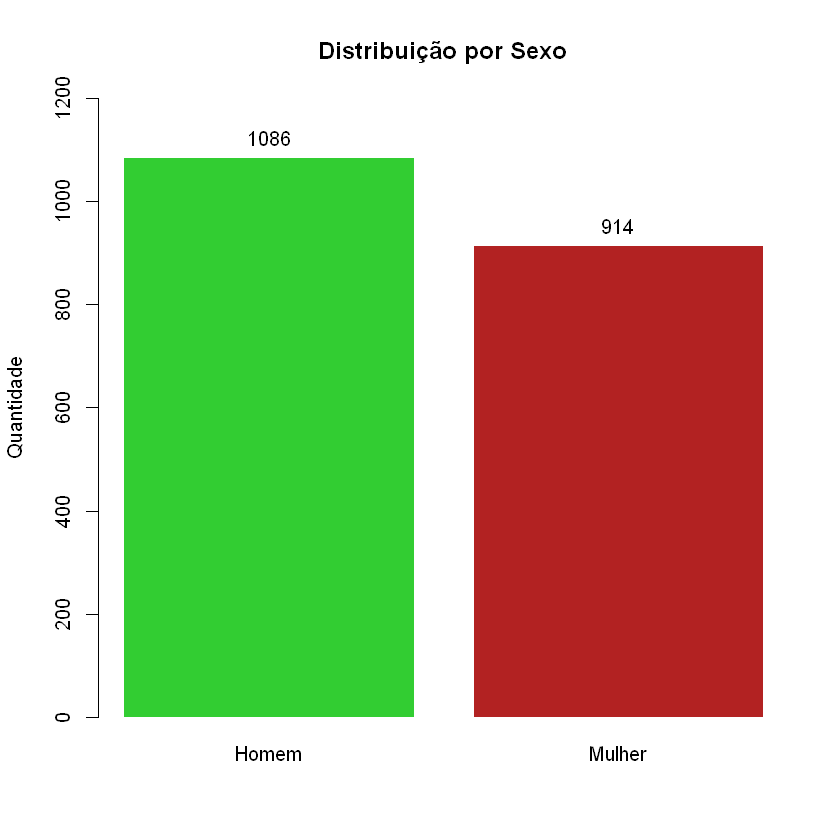

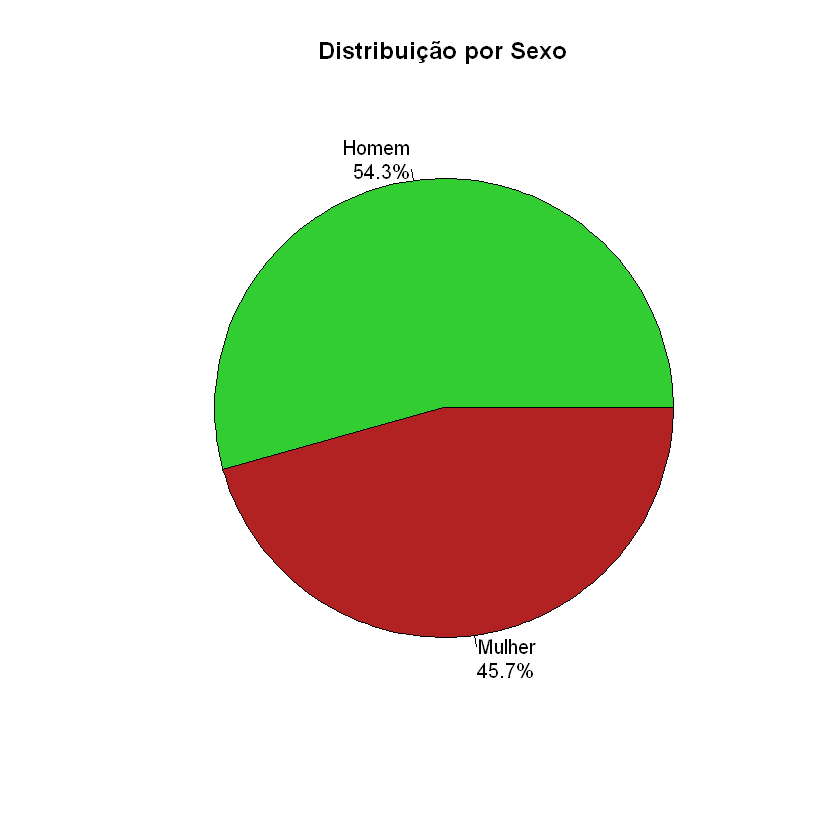

In [15]:
par(bg = "white")

Sex_var <- table(dataset_sem_id$Sex)

bp <- barplot(
    Sex_var,
    names.arg = c("Homem", "Mulher"),
    main = "Distribuição por Sexo",
    ylab = "Quantidade",
    col = c("limegreen", "firebrick"),
    border = "white",
    ylim = c(0, 1200)
)
contagem <- table(dataset_sem_id$Sex)

text(bp, contagem, labels = Sex_var, pos = 3)


pizza <- pie(
    Sex_var,
    main = "Distribuição por Sexo",
    labels = paste0(
        c("Homem", "Mulher"),
        "\n",
        round(contagem / sum(contagem) * 100, 1),
        "%"
    ),
    col = c("limegreen", "firebrick"),
    
)

No nosso dataset, percebe-se que existe uma maior represetação de homens do que mulheres, embora pequena.

### Marital Status

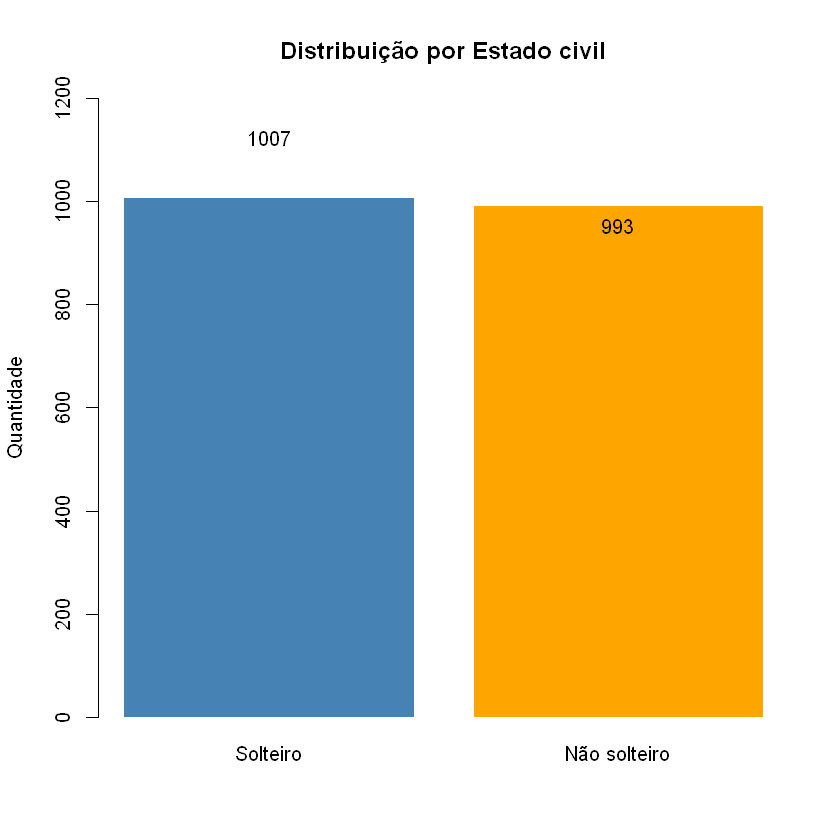

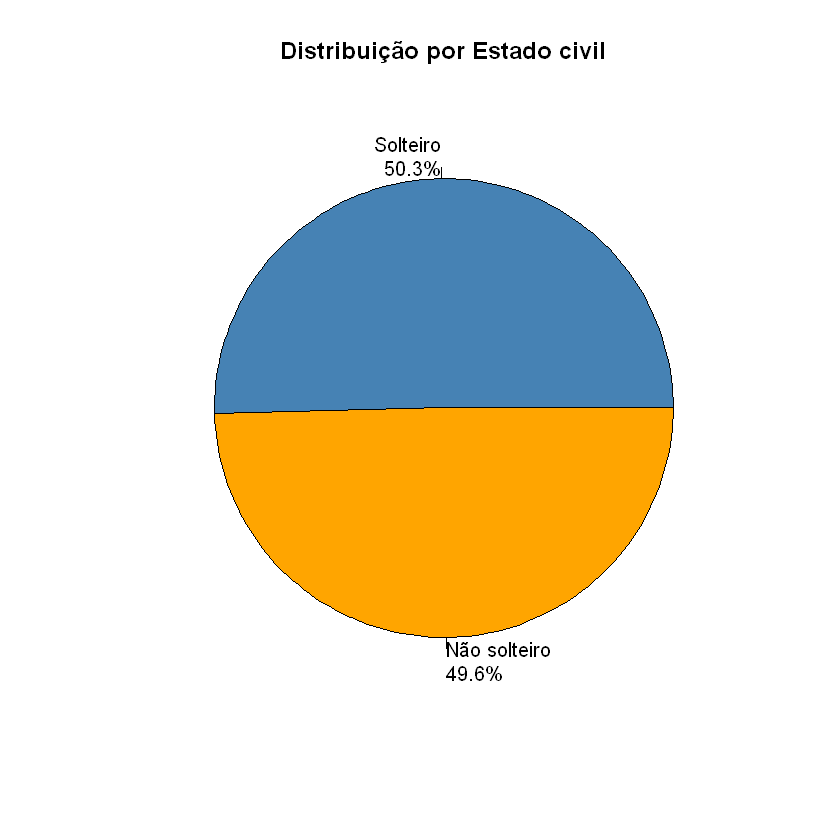

In [16]:
par(bg = "white")

Marital_var <- table(dataset_sem_id$Marital.status)

bp <- barplot(
    Marital_var,
    names.arg = c("Solteiro", "Não solteiro"),
    main = "Distribuição por Estado civil",
    ylab = "Quantidade",
    col = c("steelblue", "orange"),
    border = "white",
    ylim = c(0, 1200)
)

text(bp, contagem, labels = Marital_var, pos = 3)

contagem <- table(dataset_sem_id$Marital.status)

pizza <- pie(
    Marital_var,
    main = "Distribuição por Estado civil",
    labels = paste0(
        c("Solteiro", "Não solteiro"),
        "\n",
        round(contagem / sum(contagem) * 100, 1),
        "%"
    ),
    col = c("steelblue", "orange"),
    
)

Neste dataset, a disparidade entre as duas categorias de estado civil é baixa.

### Age

Quantidade de outliers: 57
Proporção de clientes com idade entre 20 e 40 anos: 0.7135

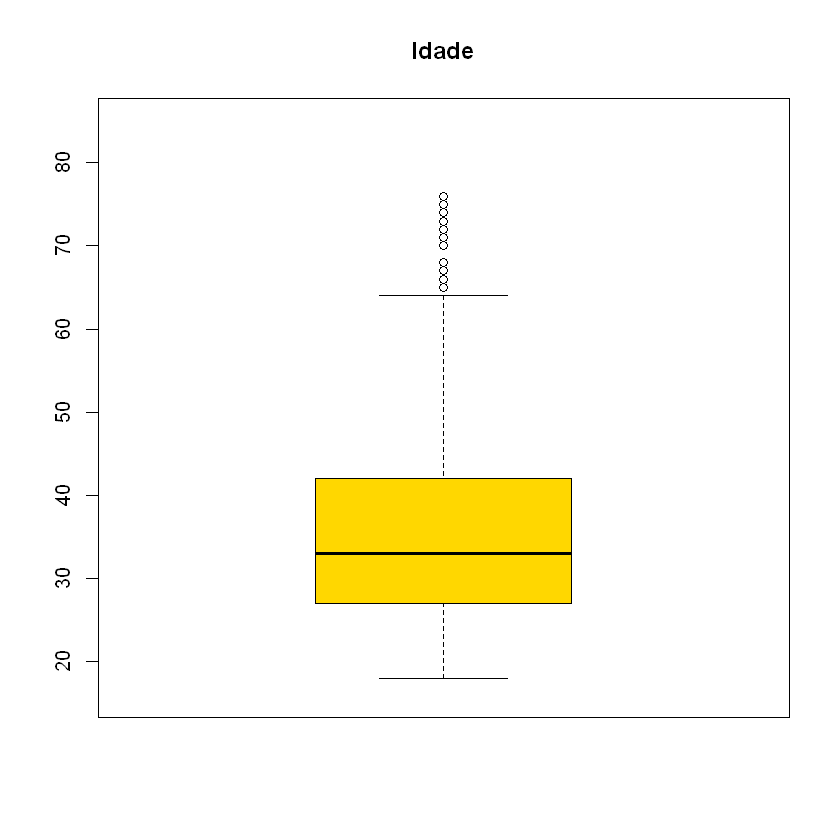

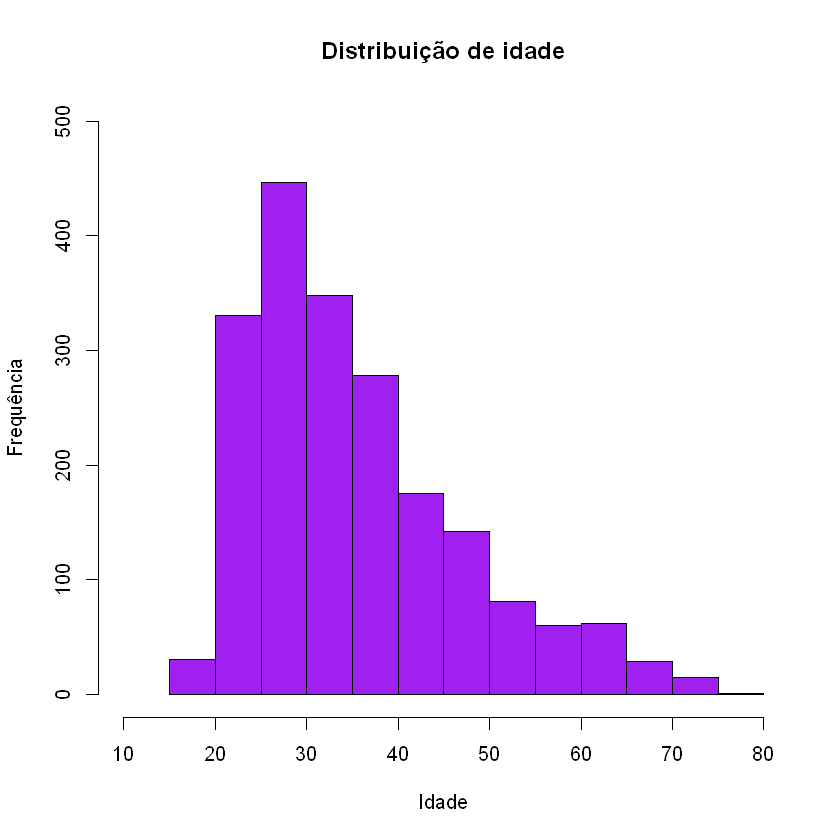

In [17]:
par(bg = "white")

Age_var <- dataset_sem_id$Age

bp <- boxplot(
    Age_var,
    main = "Idade",
    col = "gold",
    ylim = c(16, 85)
)

check_sixtyfive <- function(c) {
    cat("Quantidade de outliers:", sum(c >= 65))
}

check_sixtyfive(Age_var)
cat("\n")

check_20to40 <- function(c) {
    cat("Proporção de clientes com idade entre 20 e 40 anos:", sum(c <= 40 & c >= 20)/2000)
}

check_20to40(Age_var)

ht <- hist(
    Age_var,
    main = "Distribuição de idade",
    xlab = "Idade",
    ylab = "Frequência",
    ylim = c(0, 500),
    xlim = c(10,80),
    col = "purple"
)

A partir da análise do gráfico BoxPlot, percebemos que existem 57 *outliers*. Para definir isso, tomamos conta da fórmula de limite superior do BoxPlot, definida por:

**Limite superior = 3 Quartil + ((3 Quartil - 1 Quartil) * 1.5)**

Calculando, obtemos o valor do Limite superior como 64.5, isto é, idades acima de 65 anos são consideradas *outliers*.

A partir da análise do histograma, percebe-se que a distribuição de idade na amostra NÃO segue um modelo normal.

Outras observações seriam: Existe uma concentração de clientes com idades entre 20 e 40, os quais representam aproximadamente 71% do total de clientes; 

### Education

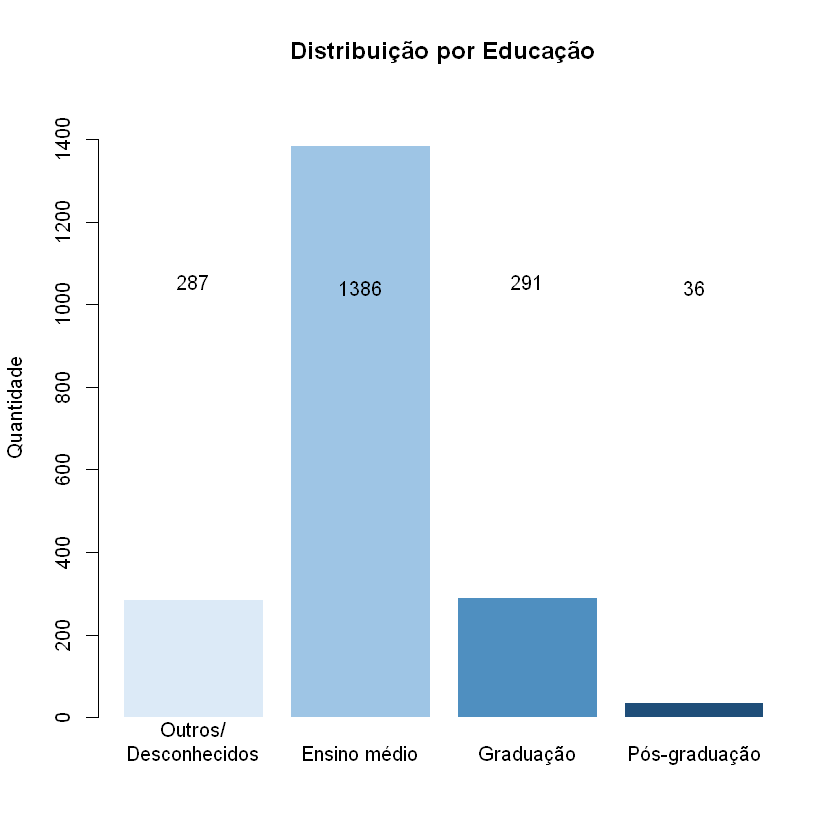

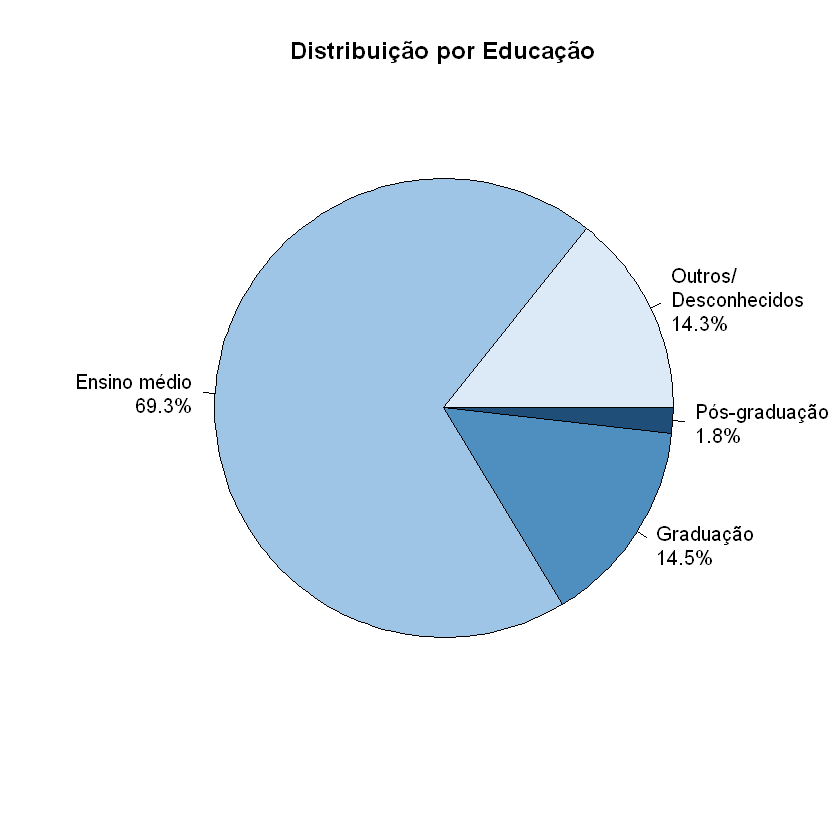

In [18]:
par(bg = "white")

Education_var <- table(dataset_sem_id$Education)

bp <- barplot(
    Education_var,
    names.arg = c("Outros/\nDesconhecidos", "Ensino médio", "Graduação", "Pós-graduação"),
    main = "Distribuição por Educação",
    ylab = "Quantidade",
    border = "white",
    ylim = c(0, 1500),
    col = c("#DCEAF7", "#9EC5E5", "#4F8FC0", "#1F4E79")
)

text(bp, contagem, labels = Education_var, pos = 3)

contagem <- table(dataset_sem_id$Education)

pizza <- pie(
    Education_var,
    main = "Distribuição por Educação",
    labels = paste0(
        c("Outros/\nDesconhecidos", "Ensino médio", "Graduação", "Pós-graduação"),
        "\n",
        round(contagem / sum(contagem) * 100, 1),
        "%"
    ),
    col = c("#DCEAF7", "#9EC5E5", "#4F8FC0", "#1F4E79")
    
)

A partir da análise dos gráficos acima, percebe-se que a amostra é composta, majoritariamente, por clientes não graduados com ensino médio completo, representando 69,3% do total. Além disso, uma quantia considerável de clientes possue escolaridade que foge a alguma das três classificações em questão (ensino médio, graduação e pós-graduação) ou possue escolaridade desconhecida.

### Income

Quantidade de outliers em relação ao limite superior: 81
Quantidade de outliers em relação ao limite inferior: 2

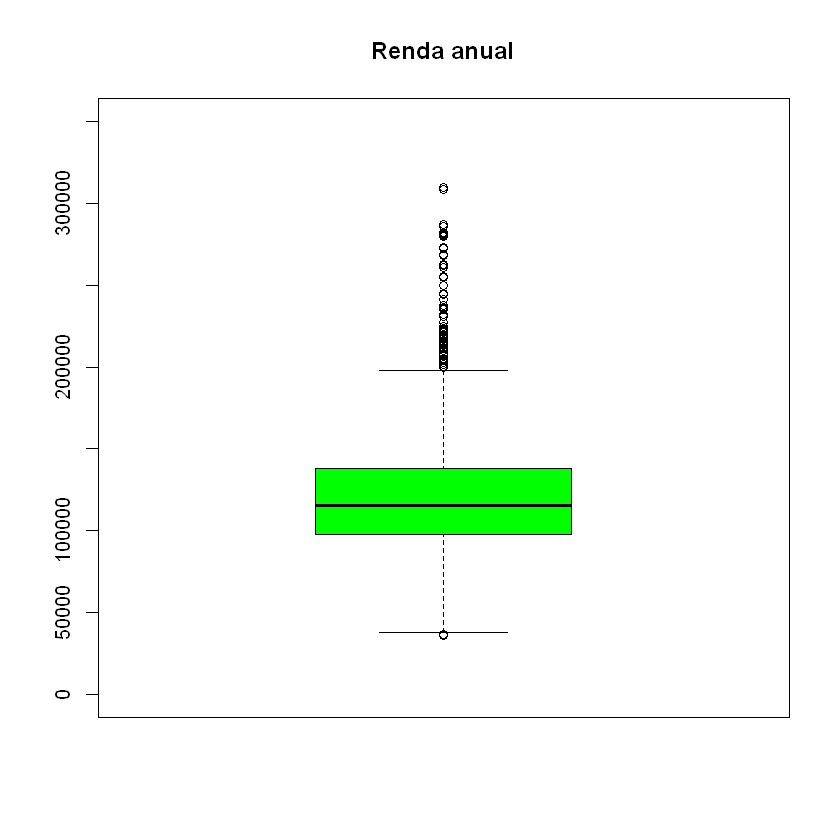

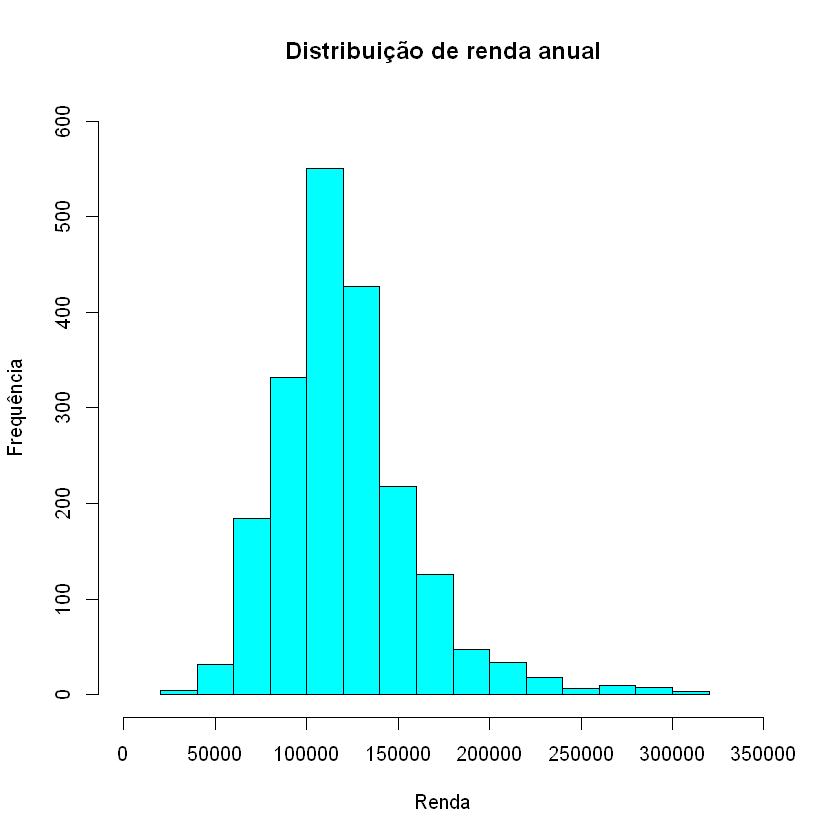

In [19]:
par(bg = "white")

Income_var <- dataset_sem_id$Income

bp <- boxplot(
    Income_var,
    main = "Renda anual",
    col = "green",
    ylim = c(0, 350000)
)

check_upper_lim <- function(c) {
    cat("Quantidade de outliers em relação ao limite superior:", sum(c > 198685.75))
}

check_lower_lim <- function(c) {
    cat("Quantidade de outliers em relação ao limite inferior:", sum(c < 37049.75))
}

check_upper_lim(Income_var)
cat("\n")
check_lower_lim(Income_var)

ht <- hist(
    Income_var,
    main = "Distribuição de renda anual",
    xlab = "Renda",
    ylab = "Frequência",
    col = "cyan",
    xlim = c(0, 350000),
    ylim = c(0, 600)
)

A partir da análise do gráfico BoxPlot, percebemos que existem 83 *outliers* totais, sendo 81 em relação ao limite superior (acima de 198685.75) e 2 em relação ao limite inferior (abaixo de 37049.75). Para definir isso, tomamos conta das fórmulas de limite superior e de limite inferior do BoxPlot, definidas por:

**Limite superior = 3 Quartil + ((3 Quartil - 1 Quartil) * 1.5)**

**Limite inferior = 1 Quartil - ((3 Quartil - 1 Quartil) * 1.5)**

Calculando, obtemos o valor do Limite superior como 198685.75, isto é, valores acima disso são considerados *outliers*. Já o limite inferior resulta em 37049.75 e valores abaixo disso também são *outliers*.

A partir da análise do histograma, percebe-se que a distribuição de renda anual na amostra NÃO segue um modelo normal. 

### Occupation

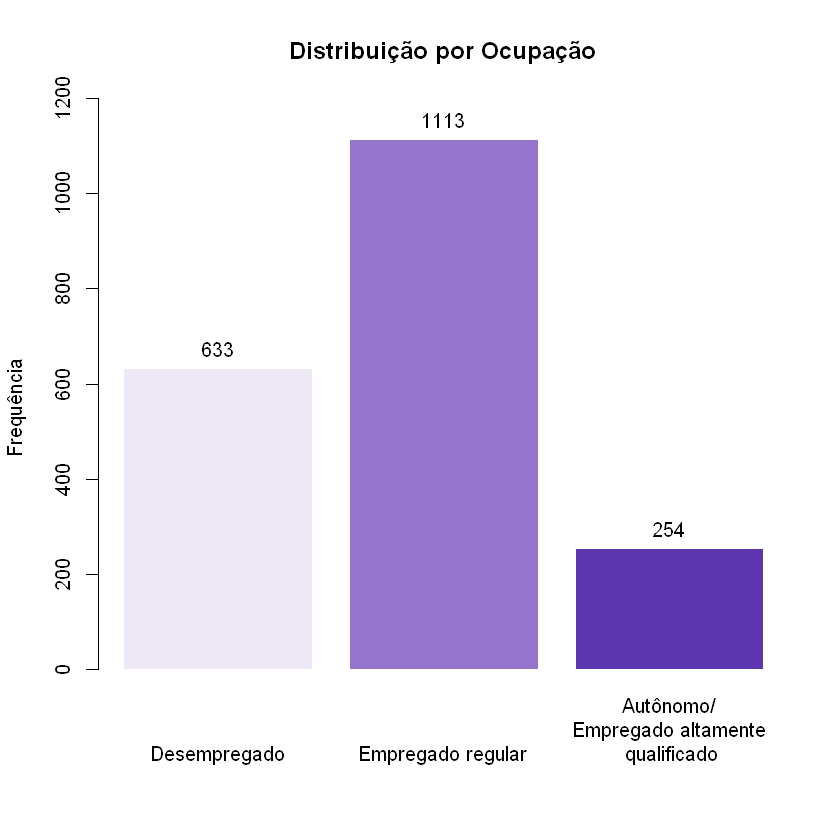

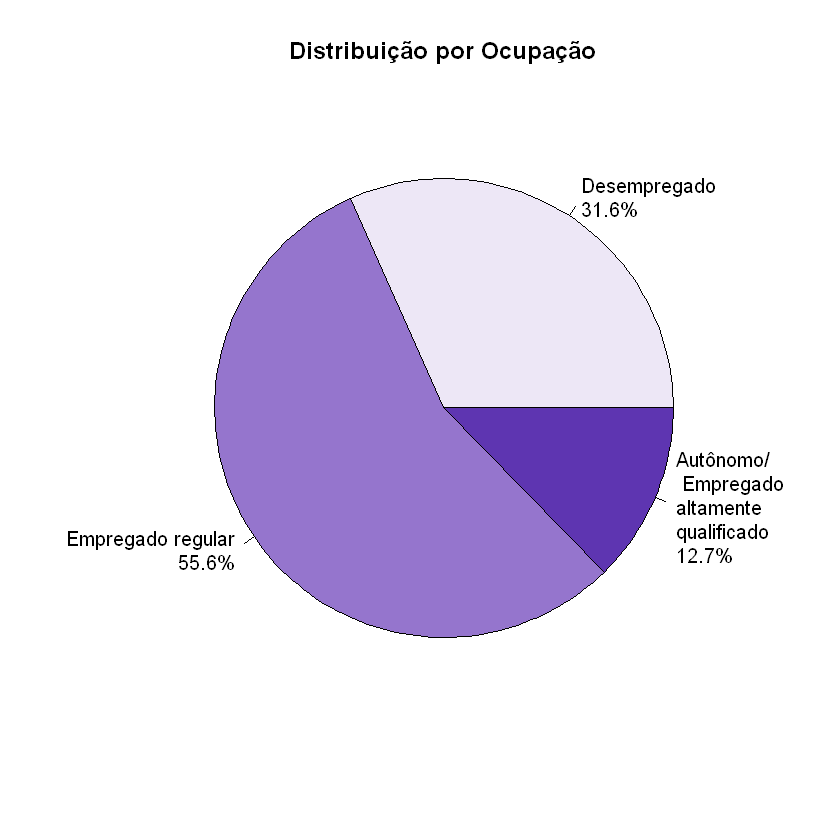

In [20]:
par(bg = "white")

Occupation_var <- table(dataset_sem_id$Occupation)

bp <- barplot(
    Occupation_var,
    names.arg = c("Desempregado", "Empregado regular", "\n Autônomo/ \n Empregado altamente \n qualificado"),
    main = "Distribuição por Ocupação",
    ylab = "Frequência",
    border = "white",
    ylim = c(-100, 1200),
    col = c("#EDE7F6", "#9575CD", "#5E35B1")
)
contagem <- table(dataset_sem_id$Occupation)

text(bp, contagem, labels = Occupation_var, pos = 3)


pizza <- pie(
    Occupation_var,
    main = "Distribuição por Ocupação",
    labels = paste0(
        c("Desempregado", "Empregado regular", "Autônomo/ \n Empregado \naltamente \nqualificado"),
        "\n",
        round(contagem / sum(contagem) * 100, 1),
        "%"
    ),
    col = c("#EDE7F6", "#9575CD", "#5E35B1")

)

A partir da análise dos gráficos de setor e de barras, percebe-se que a amostra possui uma grande quantidade de clientes em empregos regulares (55.6%) e, simultaneamente, possui um número considerável de clientes desempregados, somando quase um terço do total de clientes (31.6%).

### Settlement size

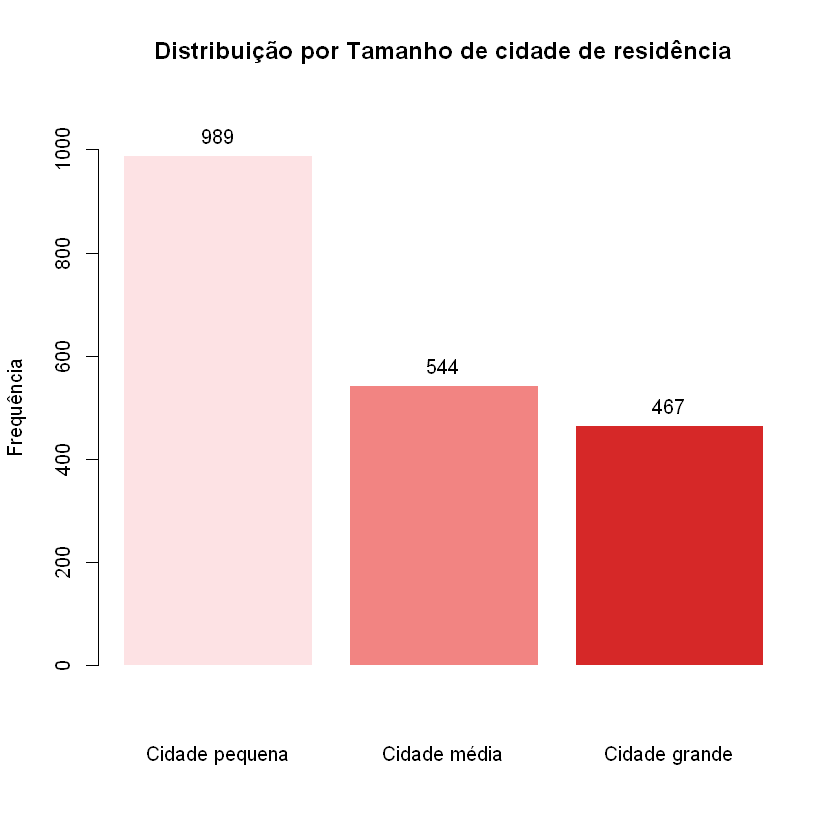

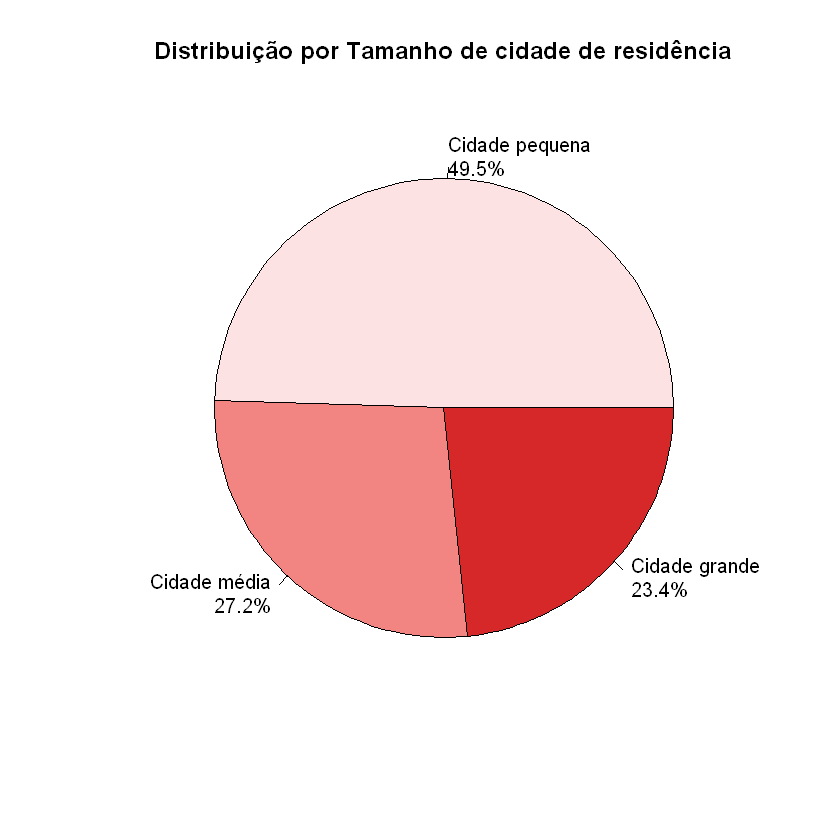

In [21]:
par(bg = "white")

Settlement_var <- table(dataset_sem_id$Settlement.size)

bp <- barplot(
    Settlement_var,
    names.arg = c("Cidade pequena", "Cidade média", "Cidade grande"),
    main = "Distribuição por Tamanho de cidade de residência",
    ylab = "Frequência",
    border = "white",
    ylim = c(-100, 1100),
    col = c("#FDE2E4", "#F28482", "#D62828")
)
contagem <- table(dataset_sem_id$Settlement.size)

text(bp, contagem, labels = Settlement_var, pos = 3)


pizza <- pie(
    Settlement_var,
    main = "Distribuição por Tamanho de cidade de residência",
    labels = paste0(
        c("Cidade pequena", "Cidade média", "Cidade grande"),
        "\n",
        round(contagem / sum(contagem) * 100, 1),
        "%"
    ),
    col = c("#FDE2E4", "#F28482", "#D62828")

)

Ao analisar os gráficos acima, é possível perceber que aproximadamente metade dos clientes da base de dados são residentes de cidades pequenas (49.5%). A outra metade dos clientes é dividida quase igualmente entre cidades médias (27.2%) e cidades grandes (23.4%).

# Análise Bivariada

### Matriz de correlação e Heatmap

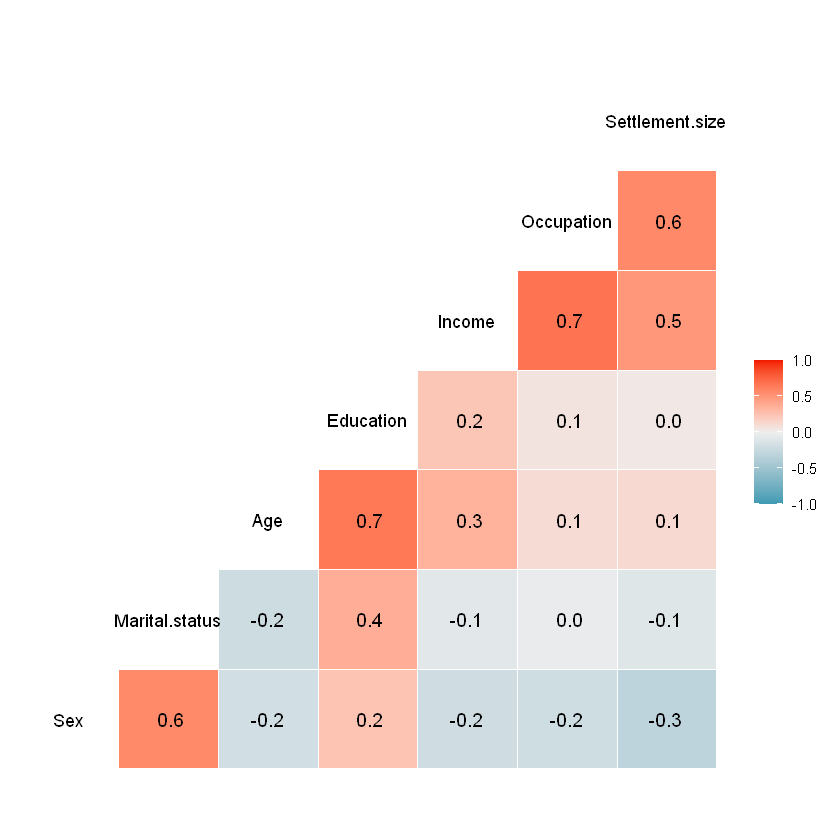

In [22]:
dataset_numerico <- dataset_sem_id[, sapply(dataset_sem_id, is.numeric)]
ggcorr(dataset_numerico, label=T)

A partir da análise do Heatmap de correlação, é possível perceber que existem múltiplas colunas que são consideravelmente correlacionadas:

* Sexo e Estado civil (taxa de correlação: 0.6)
* Idade e Educação (taxa de correlação: 0.7)
* Renda e Emprego (taxa de correlação: 0.7)
* Tamanho da cidade de residência e Emmprego (taxa de correlação: 0.6)
* Tamanho da cidade de residência e Renda (taxa de correlação: 0.5)

Além disso, existem colunas que não possuem nenhuma correlação:

* Educação e Tamanho da cidade de residência (taxa de correlação: 0)
* Estado civil e Emprego (taxa de correlação: 0)
As variáveis Renda e Idade possuem uma leve correlação (0.3), como mostra o Scatter plot abaixo.

`geom_smooth()` using formula = 'y ~ x'


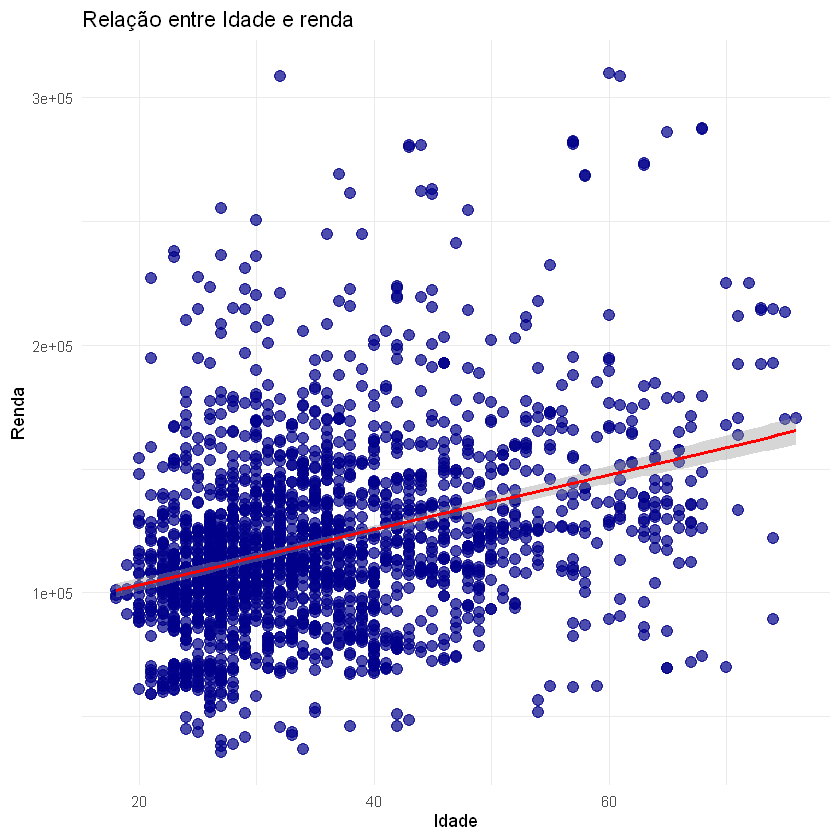

In [23]:
ggplot(dataset_sem_id, aes(x = Age, y = Income)) +
  geom_point(color = "darkblue", size = 3, alpha = 0.7) + # Os pontos
  geom_smooth(method = "lm", color = "red", se = TRUE) +  # Linha de tendência (Regressão Linear)
  theme_minimal() +                                       # Tema limpo
  labs(title = "Relação entre Idade e renda",
       x = "Idade",
       y = "Renda")

As colunas Renda e Emprego possuem alta correlação (0.7).

`geom_smooth()` using formula = 'y ~ x'


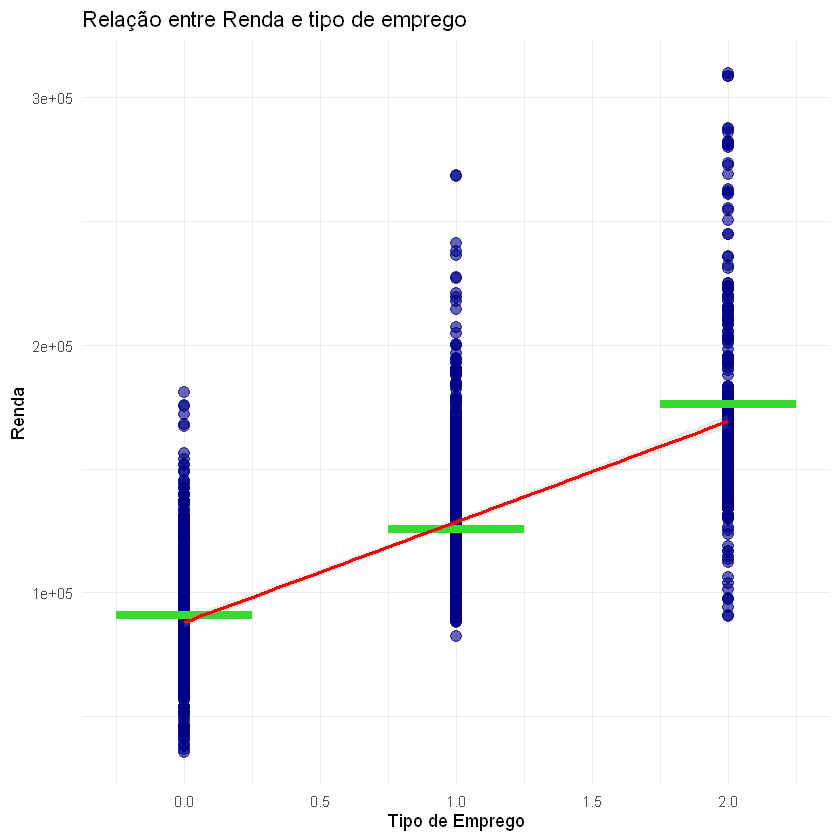

In [24]:
ggplot(dataset_sem_id, aes(x = Occupation, y = Income)) +
  geom_point(color = "darkblue", size = 3, alpha = 0.6) + 
  
  stat_summary(fun = "mean", geom = "crossbar", width = 0.5, color = "#37da2e", linewidth = 0.9) +

  geom_smooth(method = "lm", color = "red", se = TRUE, alpha = 0.2) +  

  theme_minimal() +                                       
  labs(title = "Relação entre Renda e tipo de emprego",
       x = "Tipo de Emprego",
       y = "Renda")

`geom_smooth()` using formula = 'y ~ x'


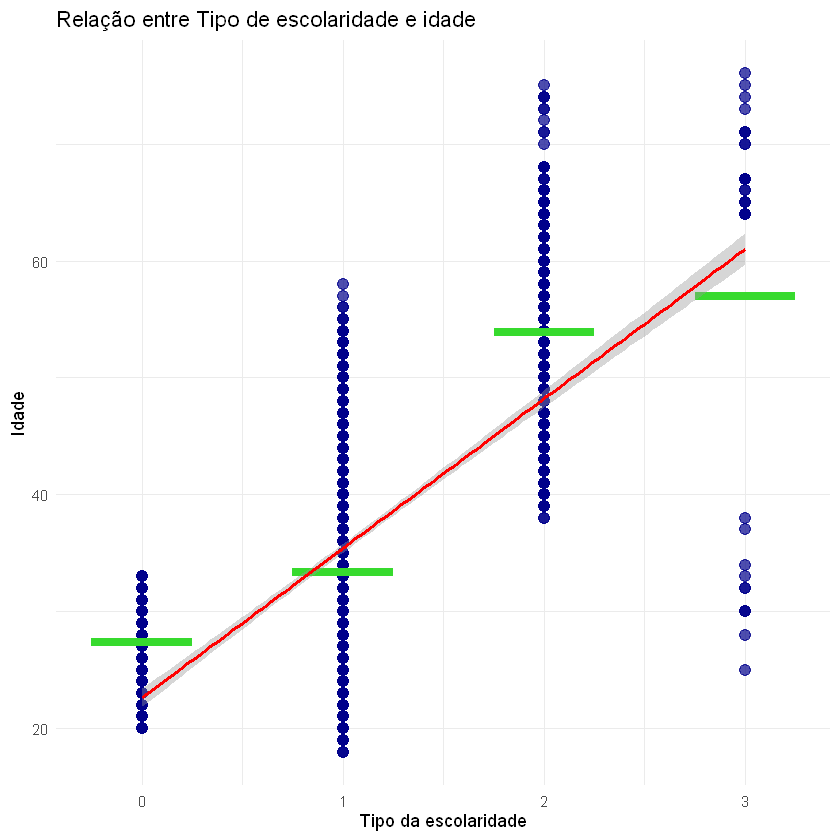

In [25]:
ggplot(dataset_sem_id, aes(x = Education, y = Age)) +
  geom_point(color = "darkblue", size = 3, alpha = 0.7) + 
  
  stat_summary(fun = "mean", geom = "crossbar", width = 0.5, color = "#37da2e", linewidth = 0.9) +
               
  geom_smooth(method = "lm", color = "red", se = TRUE) +
  theme_minimal() +                                       
  labs(title = "Relação entre Tipo de escolaridade e idade",
       x = "Tipo da escolaridade",
       y = "Idade")

## Insights


In [26]:
pca_resultado <- prcomp(dataset_sem_id, scale. = TRUE)

print(pca_resultado$rotation[, 1:2])

                       PC1         PC2
Sex              0.3146952 -0.45800608
Marital.status   0.1917044 -0.51263492
Age             -0.3260998 -0.31220793
Education       -0.1568409 -0.63980683
Income          -0.5245246 -0.12468314
Occupation      -0.4920587 -0.01465779
Settlement.size -0.4647885  0.06963165


O banco de dados escolhido possui dados de clientes de uma loja de varejo. Todas as colunas qualitativas, por padrão, já vieram com um enconding simples (nesse caso Label Encoding), onde cada tipo da variável era atribuído a um número específico que o representava unicamente. A verificação das observações e colunas do dataset a partir de funções mostrou que não existem valores faltantes e/ou duplicatas. Além disso, o banco apresenta dados consistentes no que tange à credibilidade e veracidade dos exemplos, o que pode ser confirmado ao verificar valores mínimos e máximos de colunas como idade, por exemplo, onde a idade mínima é 18 e a máxima é 76, bem como variáveis que, naturalmente, espera-se estarem correlacionadas, como o tipo de emprego e a renda. Em relação as hipóteses levantadas anteriormente, percebemos, a partir de análises bivariadas de Heatmap de correlação, que as colunas Renda e Tipo de emprego estão, de fato, fortemente correlacionadas, bem como Idade e Educação, mas as variáveis Renda e Educação não estão tão correlacionadas como esperávamos. Uma pergunta surgida após as análises é: Por que existe uma correlação forte entre Sexo e Estado civil? Dentre as variáveis mais promissoras para a modelagem, destacamos as colunas Renda (maior peso no PC1) e Educação (maior peso no PC2) de acordo com a análise do PCA.

-----------------------------------------------
# Validação Estatística (Teste de Hipóteses)
-----------------------------------------------


# Definição das Hipóteses

Vamos declarar formalmente e testar duas hipóteses que envolvem colunas correlacionadas do dataset, onde um dos testes é para uma hipótese de uma média e o outro é para uma hipótese de duas médias.

### Teste de hipótese de uma média

Teste unilateral à direita
* H0: Clientes com formação superior possuem renda media menor ou igual à média de renda populacional.
* Ha: Clientes com formação superior possuem renda média maior que a média de renda populacional.

In [27]:
cat("Média de renda da população:",mean(dataset_sem_id$Income))
cat("\n")
dados_filtrados <- dataset_sem_id[dataset_sem_id$Education %in% c(2, 3), ]
cat("Média de renda da amostra de clientes com formação superior:",mean(dados_filtrados$Income))
t.test(dados_filtrados$Income, mu = mean(dataset_sem_id$Income), alternative="greater")

Média de renda da população: 120954.4
Média de renda da amostra de clientes com formação superior: 145561.5


	One Sample t-test

data:  dados_filtrados$Income
t = 9.3915, df = 326, p-value < 2.2e-16
alternative hypothesis: true mean is greater than 120954.4
95 percent confidence interval:
 141239.4      Inf
sample estimates:
mean of x 
 145561.5 


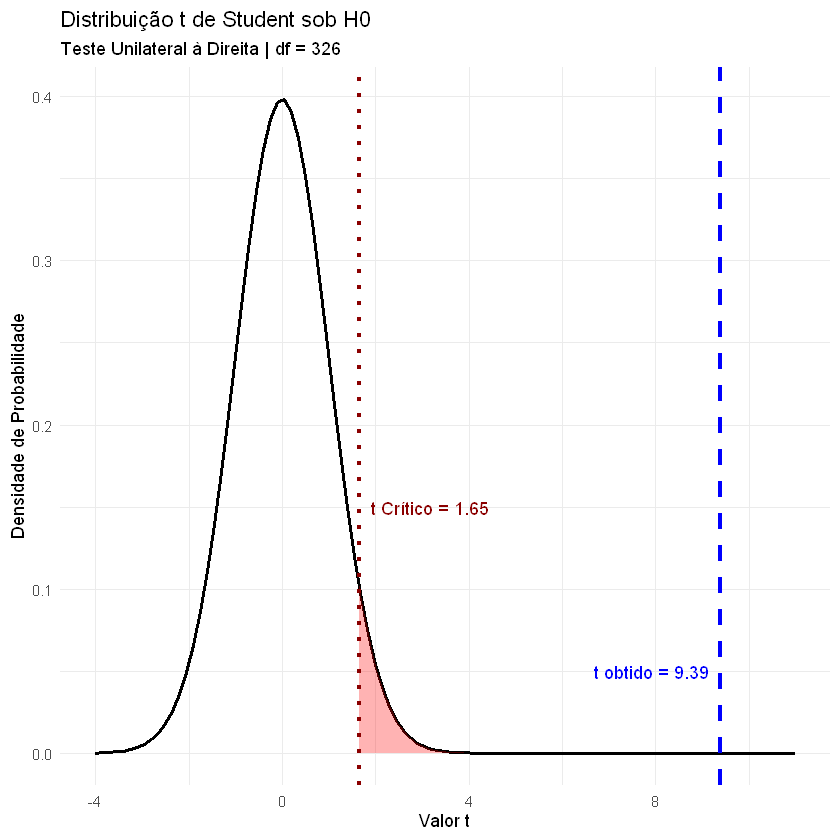

In [ ]:
# Visualizando a distribuição t para o teste unilateral à direita
t_stat <- 9.3915
df <- 326
alpha <- 0.05
t_crit <- qt(1 - alpha, df) 

ggplot(data.frame(x = c(-4, 11)), aes(x = x)) +
     stat_function(fun = dt, args = list(df = df), color = "black", linewidth = 1) +
     stat_function(fun = dt, args = list(df = df), xlim = c(t_crit, 11),
                geom = "area", fill = "red", alpha = 0.3) +
     geom_vline(xintercept = t_stat, color = "blue", linetype = "dashed", linewidth = 1.2) +
     geom_vline(xintercept = t_crit, color = "darkred", linetype = "dotted", linewidth = 1.2) +
     labs(title = "Distribuição t de Student sob H0",
       subtitle = paste("Teste Unilateral à Direita | df =", df),
       x = "Valor t", 
       y = "Densidade de Probabilidade") +
     annotate("text", x = t_stat, y = 0.05, label = paste("t obtido =", round(t_stat, 2)), color = "blue", hjust = 1.1) +
     annotate("text", x = t_crit, y = 0.15, label = paste("t Crítico =", round(t_crit, 2)), color = "darkred", hjust = -0.1) +
  theme_minimal()

A partir dos resultados obtidos pela função *t.test*, rejeitamos a hipótese nula. Ou seja, clientes com formação superior (graduação ou pós-graduação), possuem, em média, a renda maior que a população.

### Teste de hipótese de duas médias 

* H0: Não há uma diferença significativa entre as idades dos clientes homens e mulheres
* Ha: Clientes Homens tem média de idade diferente da média de idade Femininas


In [37]:
dados_filtrados_ml <- dataset_sem_id[dataset_sem_id$Sex %in% c(1), ]
cat("Média das muheres:", mean(dados_filtrados_ml$Age))
dados_filtrados_hm <- dataset_sem_id[dataset_sem_id$Sex %in% c(0), ]
cat("\nMédia dos homens:", mean(dados_filtrados_hm$Age))
t.test(Age ~ Sex, data = dataset_sem_id)

Média das muheres: 33.5733
Média dos homens: 37.87477


	Welch Two Sample t-test

data:  Age by Sex
t = 8.3183, df = 1943.1, p-value < 2.2e-16
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 3.287322 5.315609
sample estimates:
mean in group 0 mean in group 1 
       37.87477        33.57330 


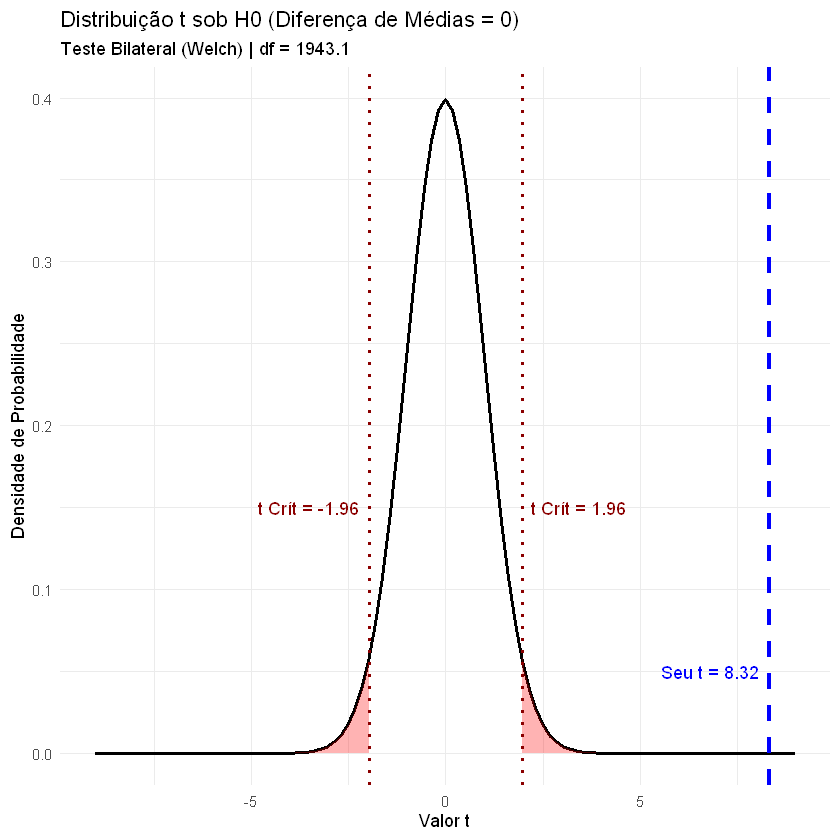

In [ ]:
#Visualizando a distribuição t para o teste bilateral 
t_stat <- 8.3183
df <- 1943.1
alpha <- 0.05

t_crit_lower <- qt(alpha / 2, df)
t_crit_upper <- qt(1 - alpha / 2, df)

x_limits <- c(-9, 9)

ggplot(data.frame(x = x_limits), aes(x = x)) +
     stat_function(fun = dt, args = list(df = df), color = "black", linewidth = 1) +  
     stat_function(fun = dt, args = list(df = df), xlim = c(-9, t_crit_lower),
                geom = "area", fill = "red", alpha = 0.3) +
     stat_function(fun = dt, args = list(df = df), xlim = c(t_crit_upper, 9),
                geom = "area", fill = "red", alpha = 0.3) +  
     geom_vline(xintercept = t_stat, color = "blue", linetype = "dashed", linewidth = 1.2) +  
     geom_vline(xintercept = t_crit_lower, color = "darkred", linetype = "dotted", linewidth = 1) +
     geom_vline(xintercept = t_crit_upper, color = "darkred", linetype = "dotted", linewidth = 1) +

     labs(title = "Distribuição t sob H0 (Diferença de Médias = 0)",
       subtitle = paste("Teste Bilateral | df =", round(df, 1)),
       x = "Valor t", 
       y = "Densidade de Probabilidade") +  
     annotate("text", x = t_stat, y = 0.05, label = paste("Seu t =", round(t_stat, 2)), color = "blue", hjust = 1.1) +
     annotate("text", x = t_crit_upper, y = 0.15, label = paste("t Crít =", round(t_crit_upper, 2)), color = "darkred", hjust = -0.1) +
     annotate("text", x = t_crit_lower, y = 0.15, label = paste("t Crít =", round(t_crit_lower, 2)), color = "darkred", hjust = 1.1) +

  theme_minimal()


A partir dos resultados obtidos pela função *t.test*, rejeitamos a hipótese nula. Ou seja, neste dataset, homens tem, em média, idade diferente do que mulheres em média possuem.

-----------------------------------------------
# Pré-processamento, Aplicação da Técnica e Resultados
-----------------------------------------------


Para preparar nosso dataset antes de aplicar o algoritmo de clusterização, aplicamos uma normalização de escala nas colunas para evitar que variáveis com grandezas maiores dominem a criação dos clusters.

In [29]:
# Primeiramente, normalizamos as colunas do dataset
dataset_final<- as.data.frame(scale(dataset_sem_id))
head(dataset_final)

,Sex,Marital.status,Age,Education,Income,Occupation,Settlement.size
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-0.9171695,-0.992776,2.65295099,1.60392184,0.09749923,0.2967488,1.5519379
2,1.0897659,1.006773,-1.18683527,-0.06335658,0.78245869,0.2967488,1.5519379
3,-0.9171695,-0.992776,1.11703649,-0.06335658,-0.83299391,-1.2692080,-0.9095021
4,-0.9171695,-0.992776,0.77572215,-0.06335658,1.32805410,0.2967488,0.3212179
5,-0.9171695,-0.992776,1.45835082,-0.06335658,0.73674749,0.2967488,0.3212179
6,-0.9171695,-0.992776,-0.07756368,-0.06335658,0.62698289,-1.2692080,-0.9095021


Como parte essencial da fase de tunagem de hiperparâmetros do K-means, aplicaremos dois métodos para definir o valor ideal de centroides: Elbow method e Gap method

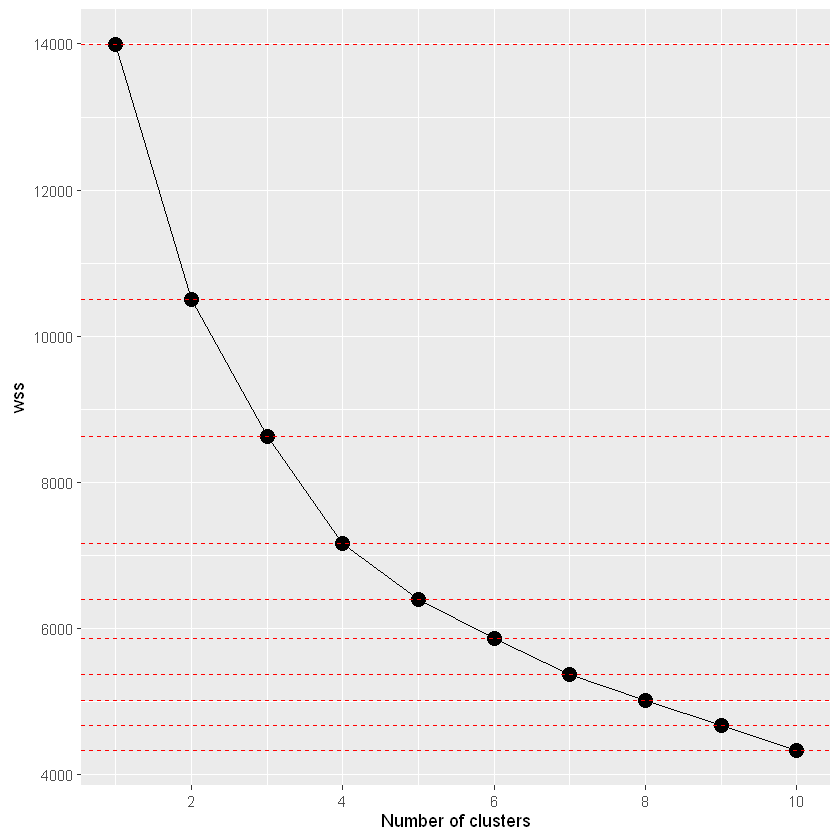

In [30]:
# Elbow Method
n_clusters <- 10

wss <- numeric(n_clusters)

set.seed(123)

for (i in 1:n_clusters) {
  km.out <- kmeans(dataset_final, centers = i, nstart = 20)
  wss[i] <- km.out$tot.withinss
}

wss_df <- tibble(clusters = 1:n_clusters, wss = wss)

scree_plot <- ggplot(wss_df, aes(x = clusters, y = wss, group = 1)) +
    geom_point(size = 4)+
    geom_line() +
    scale_x_continuous(breaks = c(2, 4, 6, 8, 10)) +
    xlab('Number of clusters')

scree_plot +
  geom_hline(
    yintercept = wss,
    linetype = 'dashed',
    color = 'red',
    linewidth = 0.5
  )

Seguindo o método do cotovelo, o valor ideal seria aquele que possui a maior variação no valor de WSS entre dois valores consecutivos de K e que seja precedido de uma queda significativa nessa variação, formando, visualmente, um "cotovelo". Neste caso, o valor ideal seria de K = 4.

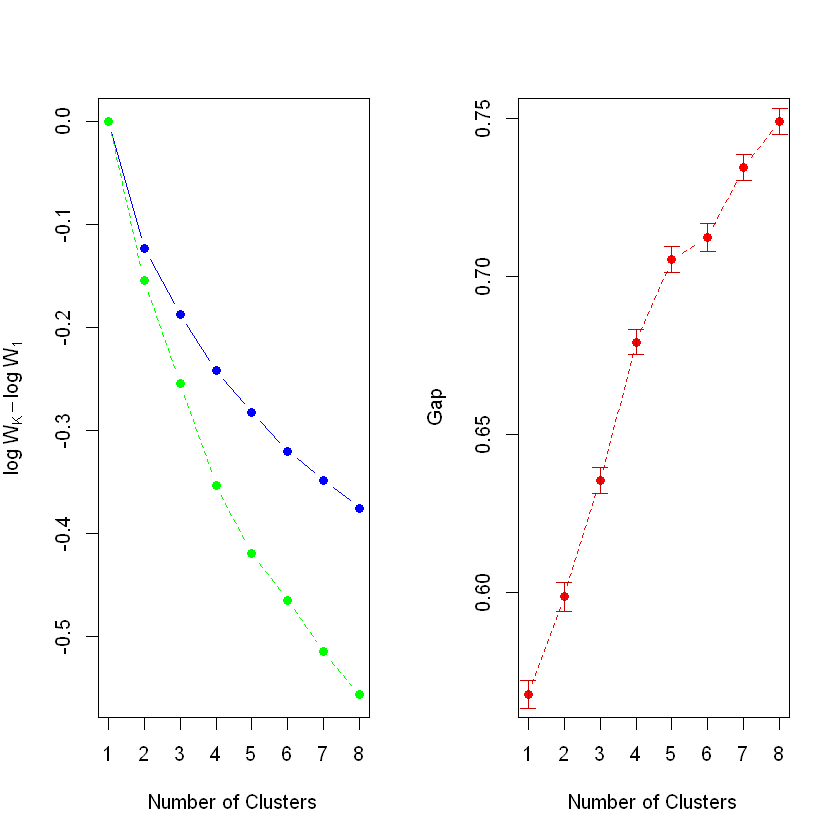

In [ ]:
# Gap Method
gaps_calculados <- clusGap(
  dataset_final, 
  FUNcluster = function(x, k) kmeans(x, centers = k, iter.max = 50, nstart = 25), 
  K.max = 8, 
  B = 100
)

tabela_gap <- as.data.frame(gaps_calculados$Tab)
K_valores <- 1:nrow(tabela_gap)


logW_norm   <- tabela_gap$logW - tabela_gap$logW[1]
E_logW_norm <- tabela_gap$E.logW - tabela_gap$E.logW[1] 

par(mfrow = c(1, 2), bg = "white")



ylim_g1 <- range(c(logW_norm, E_logW_norm))


plot(
  K_valores, E_logW_norm, 
  type = "b", pch = 16, col = "blue", lty = 1,
  ylim = ylim_g1, xaxt = "n",
  xlab = "Number of Clusters", ylab = expression(log ~ W[K] - log ~ W[1])
)
axis(1, at = K_valores)


lines(K_valores, logW_norm, type = "b", pch = 16, col = "green", lty = 2)


plot(
  gaps_calculados, 
  col = "red", lty = 2, pch = 16,
  main = "", 
  xlab = "Number of Clusters", ylab = "Gap",
  xaxt = "n"
)
axis(1, at = K_valores)


par(mfrow = c(1, 1))

Analisando o gráfico obtido pela aplicação do método Gap, e tomando em conta as características do dataset trabalhado, o qual possui uma quantidade considerável de *outliers*, torna-se necessário analisar o resultado do Gap de maneira não convencional, focando no valor de K que possui a maior variação no valor da função Gap seguido de uma queda nessa variação, uma análise similar ao que é feito no método do cotovelo. Portanto, K = 4 segue sendo nosso valor ideal.

In [ ]:
# Execução do K-means para K = 4
set.seed(123)
km.out <- kmeans(dataset_final, centers = 4, nstart = 20)
print(km.out)

K-means clustering with 4 clusters of sizes 705, 263, 462, 570

Cluster means:
          Sex Marital.status         Age   Education     Income Occupation
1  0.79655407      1.0011004 -0.59268205  0.05016025 -0.3987344 -0.2763247
2  0.09011369      0.3909422  1.68902999  1.81946354  0.9809802  0.4991919
3 -0.20909486     -0.9538238 -0.02825041 -0.48558943 -0.6060162 -0.7540014
4 -0.85731349     -0.6454860 -0.02337255 -0.50796416  0.5317359  0.7225792
  Settlement.size
1      -0.3892828
2       0.4569247
3      -0.8562241
4       0.9646469

Clustering vector:
   [1] 2 1 3 4 4 3 4 4 2 4 1 1 1 3 1 1 3 4 2 4 4 4 3 4 4 3 3 2 4 2 4 4 4 3 1 3 4
  [38] 4 4 4 4 1 3 4 2 1 3 1 3 1 3 4 4 3 2 3 4 1 1 1 4 4 2 4 1 4 1 1 4 1 1 3 4 1
  [75] 4 2 4 4 3 1 2 4 1 2 3 1 1 4 4 4 4 4 1 4 4 2 2 4 4 4 3 3 1 4 1 4 4 4 1 1 4
 [112] 1 4 1 4 4 1 1 1 4 1 2 3 2 1 4 3 4 4 1 1 4 3 4 1 1 4 2 4 1 1 1 4 4 1 4 1 2
 [149] 4 4 3 4 4 4 4 1 4 1 4 3 4 1 4 2 4 4 1 1 1 4 3 1 4 3 4 2 2 4 4 2 4 4 3 4 4
 [186] 4 2 3 1 1 4 3 4 1 4 4 1 

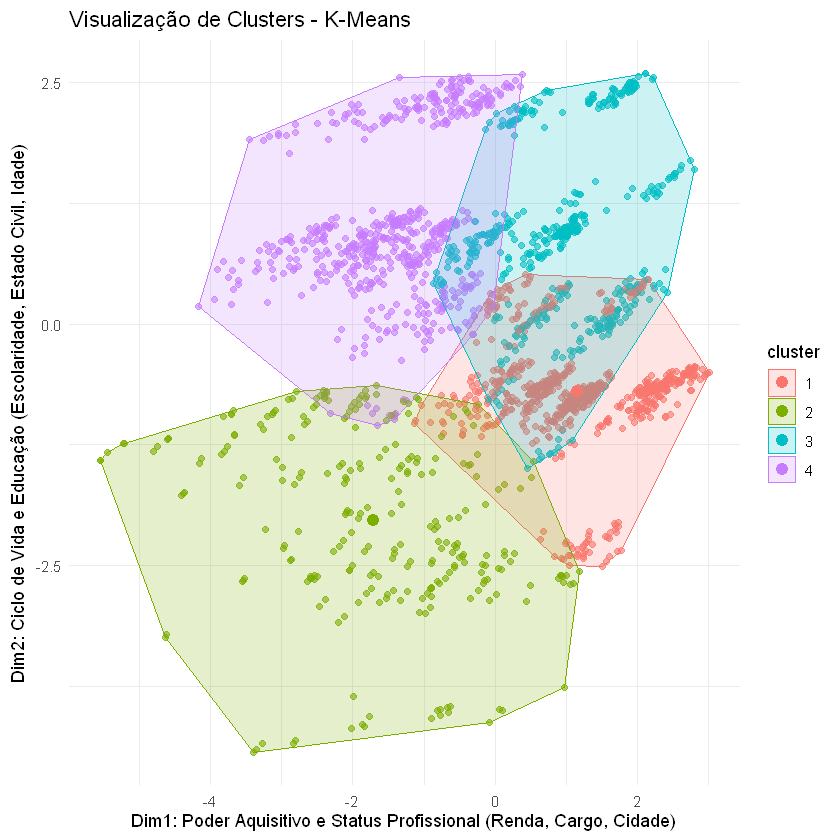

In [ ]:
library(factoextra)

fviz_cluster(
  km.out, 
  data = dataset_final,
  
  geom = c("point"),          
  pointsize = 1.5,             
  shape = 19,                  
  alpha = 0.6,               
  ellipse.type = "convex",     
  ellipse.level = 0.95,
  main = "Visualização de Clusters - K-Means" 
) +
  
  labs(
    x = "Dim1: Poder Aquisitivo e Status Profissional (Renda, Cargo, Cidade)",
    y = "Dim2: Ciclo de Vida e Educação (Escolaridade, Estado Civil, Idade)"
  ) +
  
  theme_minimal()             

In [ ]:
# Execução do K-Means com inicalização ++
dataset_final_matrix <- as.matrix(dataset_final)

set.seed(12)
k_meanspp <- kmeanspp(dataset_final_matrix, k = 4)

print(k_meanspp)

   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
   1    4    3    3    3    3    3    2    1    2    4    4    4    3    4    4 
  17   18   19   20   21   22   23   24   25   26   27   28   29   30   31   32 
   3    3    1    3    3    3    3    3    4    3    3    1    3    1    3    3 
  33   34   35   36   37   38   39   40   41   42   43   44   45   46   47   48 
   3    3    4    3    3    3    3    3    2    3    3    3    1    4    3    4 
  49   50   51   52   53   54   55   56   57   58   59   60   61   62   63   64 
   3    4    3    2    3    3    1    3    2    4    4    4    4    3    1    2 
  65   66   67   68   69   70   71   72   73   74   75   76   77   78   79   80 
   4    3    4    3    3    4    4    3    2    1    2    1    3    3    3    3 
  81   82   83   84   85   86   87   88   89   90   91   92   93   94   95   96 
   1    3    4    1    3    4    4    2    2    3    3    3    4    3    3    1 
  97   98   99  100  101  10

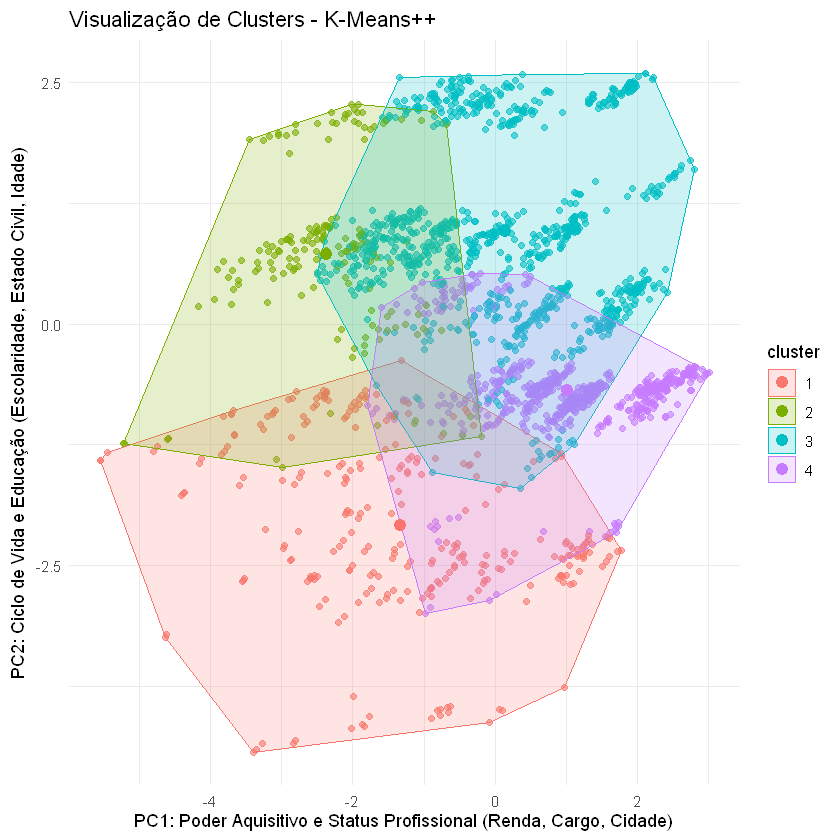

In [35]:
fviz_cluster(
  object = list(data = dataset_final, cluster = k_meanspp),
  

  geom = c("point"),           
  pointsize = 1.5,            
  shape = 19,                  
  alpha = 0.6,                
  ellipse.type = "convex",    
  ellipse.level = 0.95,
  main = "Visualização de Clusters - K-Means++" 
) +
  # Usando aquela definição inteligente de eixos que descobrimos no PCA!
  labs(
    x = "PC1: Poder Aquisitivo e Status Profissional (Renda, Cargo, Cidade)",
    y = "PC2: Ciclo de Vida e Educação (Escolaridade, Estado Civil, Idade)"
  ) +
  theme_minimal()

In [36]:
dataset_com_clusters <- dataset_sem_id %>%
  mutate(cluster = km.out$cluster)

grupo_1 <- dataset_com_clusters %>% 
  filter(cluster == 1)

cat("grupo 1:",dim(grupo_1))
summary(grupo_1)

grupo_2 <- dataset_com_clusters %>% 
  filter(cluster == 2)

cat("\n")

cat("grupo 2:",dim(grupo_2))
summary(grupo_2)

grupo_3 <- dataset_com_clusters %>% 
  filter(cluster == 3)

cat("\n")

cat("grupo 3:",dim(grupo_3))
summary(grupo_3)

grupo_4 <- dataset_com_clusters %>% 
  filter(cluster == 4)

cat("\n")

cat("grupo 4:", dim(grupo_4))
summary(grupo_4)


grupo 1: 705 8

      Sex         Marital.status        Age          Education    
 Min.   :0.0000   Min.   :0.0000   Min.   :18.00   Min.   :1.000  
 1st Qu.:1.0000   1st Qu.:1.0000   1st Qu.:24.00   1st Qu.:1.000  
 Median :1.0000   Median :1.0000   Median :27.00   Median :1.000  
 Mean   :0.8539   Mean   :0.9972   Mean   :28.96   Mean   :1.068  
 3rd Qu.:1.0000   3rd Qu.:1.0000   3rd Qu.:32.00   3rd Qu.:1.000  
 Max.   :1.0000   Max.   :1.0000   Max.   :59.00   Max.   :2.000  
     Income         Occupation    Settlement.size     cluster 
 Min.   : 35832   Min.   :0.000   Min.   :0.0000   Min.   :1  
 1st Qu.: 92304   1st Qu.:0.000   1st Qu.:0.0000   1st Qu.:1  
 Median :106577   Median :1.000   Median :0.0000   Median :1  
 Mean   :105759   Mean   :0.634   Mean   :0.4227   Mean   :1  
 3rd Qu.:120326   3rd Qu.:1.000   3rd Qu.:1.0000   3rd Qu.:1  
 Max.   :207262   Max.   :2.000   Max.   :2.0000   Max.   :1  


grupo 2: 263 8

      Sex         Marital.status       Age         Education    
 Min.   :0.0000   Min.   :0.000   Min.   :25.0   Min.   :1.000  
 1st Qu.:0.0000   1st Qu.:0.000   1st Qu.:47.0   1st Qu.:2.000  
 Median :1.0000   Median :1.000   Median :57.0   Median :2.000  
 Mean   :0.5019   Mean   :0.692   Mean   :55.7   Mean   :2.129  
 3rd Qu.:1.0000   3rd Qu.:1.000   3rd Qu.:64.0   3rd Qu.:2.000  
 Max.   :1.0000   Max.   :1.000   Max.   :76.0   Max.   :3.000  
     Income         Occupation    Settlement.size    cluster 
 Min.   : 69487   Min.   :0.000   Min.   :0.00    Min.   :2  
 1st Qu.:128307   1st Qu.:1.000   1st Qu.:1.00    1st Qu.:2  
 Median :146716   Median :1.000   Median :1.00    Median :2  
 Mean   :158338   Mean   :1.129   Mean   :1.11    Mean   :2  
 3rd Qu.:172774   3rd Qu.:2.000   3rd Qu.:2.00    3rd Qu.:2  
 Max.   :309364   Max.   :2.000   Max.   :2.00    Max.   :2  


grupo 3: 462 8

      Sex         Marital.status         Age          Education     
 Min.   :0.0000   Min.   :0.00000   Min.   :19.00   Min.   :0.0000  
 1st Qu.:0.0000   1st Qu.:0.00000   1st Qu.:28.00   1st Qu.:0.0000  
 Median :0.0000   Median :0.00000   Median :35.00   Median :1.0000  
 Mean   :0.3528   Mean   :0.01948   Mean   :35.58   Mean   :0.7468  
 3rd Qu.:1.0000   3rd Qu.:0.00000   3rd Qu.:41.00   3rd Qu.:1.0000  
 Max.   :1.0000   Max.   :1.00000   Max.   :68.00   Max.   :2.0000  
     Income         Occupation    Settlement.size      cluster 
 Min.   : 36760   Min.   :0.000   Min.   :0.00000   Min.   :3  
 1st Qu.: 79145   1st Qu.:0.000   1st Qu.:0.00000   1st Qu.:3  
 Median : 99102   Median :0.000   Median :0.00000   Median :3  
 Mean   : 97860   Mean   :0.329   Mean   :0.04329   Mean   :3  
 3rd Qu.:113595   3rd Qu.:1.000   3rd Qu.:0.00000   3rd Qu.:3  
 Max.   :171857   Max.   :1.000   Max.   :1.00000   Max.   :3  


grupo 4: 570 8

      Sex          Marital.status        Age          Education     
 Min.   :0.00000   Min.   :0.0000   Min.   :20.00   Min.   :0.0000  
 1st Qu.:0.00000   1st Qu.:0.0000   1st Qu.:29.00   1st Qu.:0.0000  
 Median :0.00000   Median :0.0000   Median :35.00   Median :1.0000  
 Mean   :0.02982   Mean   :0.1737   Mean   :35.64   Mean   :0.7333  
 3rd Qu.:0.00000   3rd Qu.:0.0000   3rd Qu.:41.00   3rd Qu.:1.0000  
 Max.   :1.00000   Max.   :1.0000   Max.   :58.00   Max.   :1.0000  
     Income         Occupation    Settlement.size    cluster 
 Min.   : 82398   Min.   :0.000   Min.   :0.000   Min.   :4  
 1st Qu.:116896   1st Qu.:1.000   1st Qu.:1.000   1st Qu.:4  
 Median :135629   Median :1.000   Median :2.000   Median :4  
 Mean   :141218   Mean   :1.272   Mean   :1.523   Mean   :4  
 3rd Qu.:157468   3rd Qu.:2.000   3rd Qu.:2.000   3rd Qu.:4  
 Max.   :268906   Max.   :2.000   Max.   :2.000   Max.   :4  

In [41]:
dataset_sem_id$Cluster <- km.out$cluster

# 2. Agrupamos por Cluster e calculamos a média de todas as colunas reais
medias_reais <- dataset_sem_id %>%
  group_by(Cluster) %>%
  summarise(across(everything(), mean, na.rm = TRUE))

# Imprime o resultado idêntico ao km.out$centers, mas com os valores da vida real!
# Converte para data frame tradicional para forçar a exibição de todas as casas decimais
cat("Médias de valores de cada variável para cada cluster:\n\n")
print(as.data.frame(medias_reais))

Médias de valores de cada variável para cada cluster:

  Cluster        Sex Marital.status      Age Education    Income Occupation
1       1 0.85390071     0.99716312 28.96312 1.0680851 105759.12  0.6340426
2       2 0.50190114     0.69201521 55.70342 2.1292776 158338.42  1.1292776
3       3 0.35281385     0.01948052 35.57792 0.7467532  97859.85  0.3290043
4       4 0.02982456     0.17368421 35.63509 0.7333333 141218.25  1.2719298
  Settlement.size
1      0.42269504
2      1.11026616
3      0.04329004
4      1.52280702


-----------------------------------------------
# Interpretação
-----------------------------------------------

**O nosso modelo identificou 4 clusters no total.**

**Analisando as médias finais de cada variável para cada cluster, podemos chegar nas seguintes explicações:**

### Cluster 1: Mulheres Jovens de Renda Básica e Cidades Pequenas
É caracterizado por mulheres não solteiras, jovens, com aproximadamente 28 anos,
com ensino médio completo, com renda abaixo da média,
ocupação regular ou sem ocupação e de cidade pequena.

### Cluster 2: Adultos Maduros de Alta Escolaridade e Renda
Este grupo destaca-se principalmente por seus marcadores de idade, renda e escolaridade. É formado por clientes com média de 55 anos, rendimentos acima da média e formação em nível de graduação ou pós-graduação. Embora a distribuição por sexo seja equilibrada, nota-se uma leve predominância de indivíduos não solteiros. O perfil se completa por profissionais que exercem ocupações regulares ou de alto rendimento e residem em cidades de médio porte.

### Cluster 3: Homens Solteiros de Baixa Qualificação e Renda
Este grupo é predominantemente masculino e composto quase inteiramente por indivíduos solteiros, com média de idade de 35 anos. Caracteriza-se por indicadores socioeconômicos mais baixos, apresentando escolaridade inferior ao ensino médio completo e rendimentos abaixo da média geral. Há uma forte incidência de desemprego ou inatividade profissional, com os indivíduos residindo quase exclusivamente em cidades de pequeno porte.

### Cluster 4: Homens Solteiros de Renda Ativa em Centros Urbanos
Este cluster é composto quase exclusivamente por homens, com forte tendência a serem solteiros e média de idade de 35 anos. Em relação aos indicadores socioeconômicos, o grupo apresenta escolaridade média inferior ao ensino médio completo e renda acima da média. Adicionalmente, os indivíduos tendem a manter emprego regular e residem, predominantemente, em cidades de médio a grande porte.


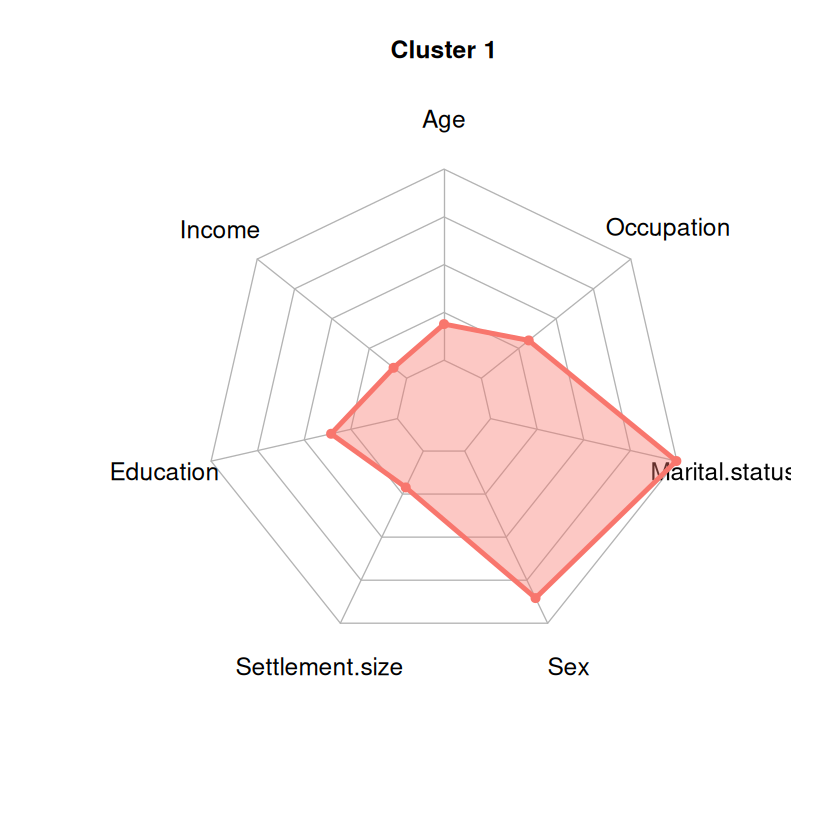

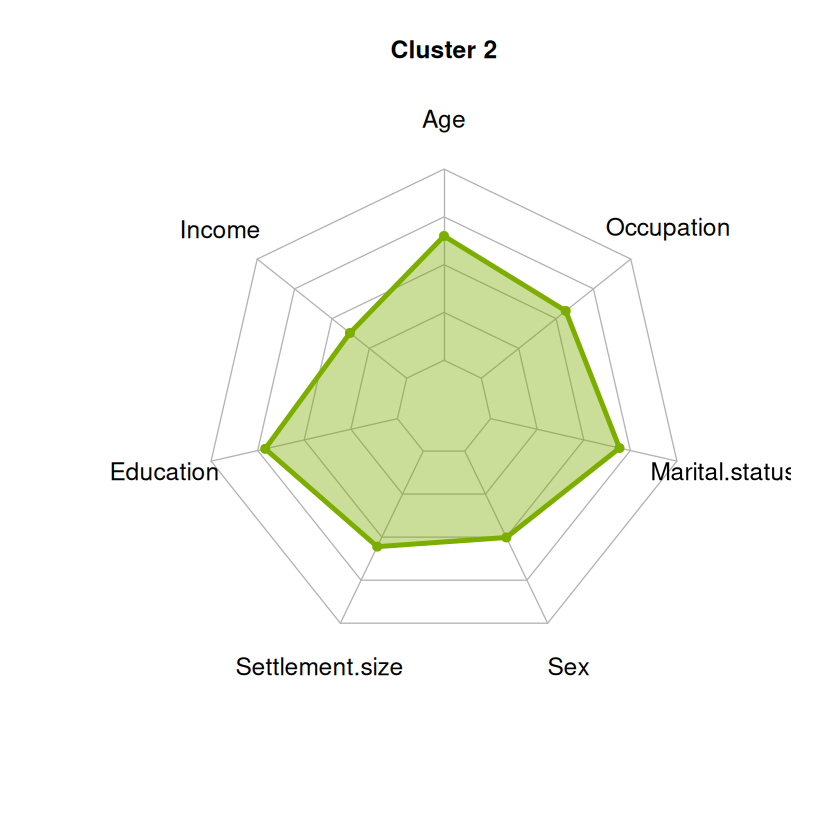

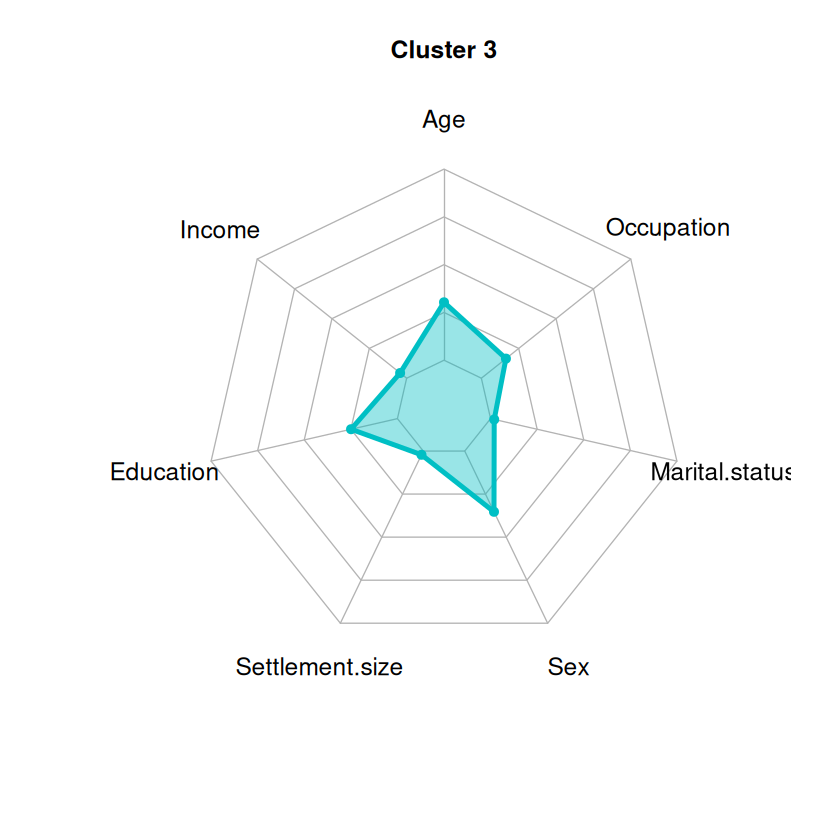

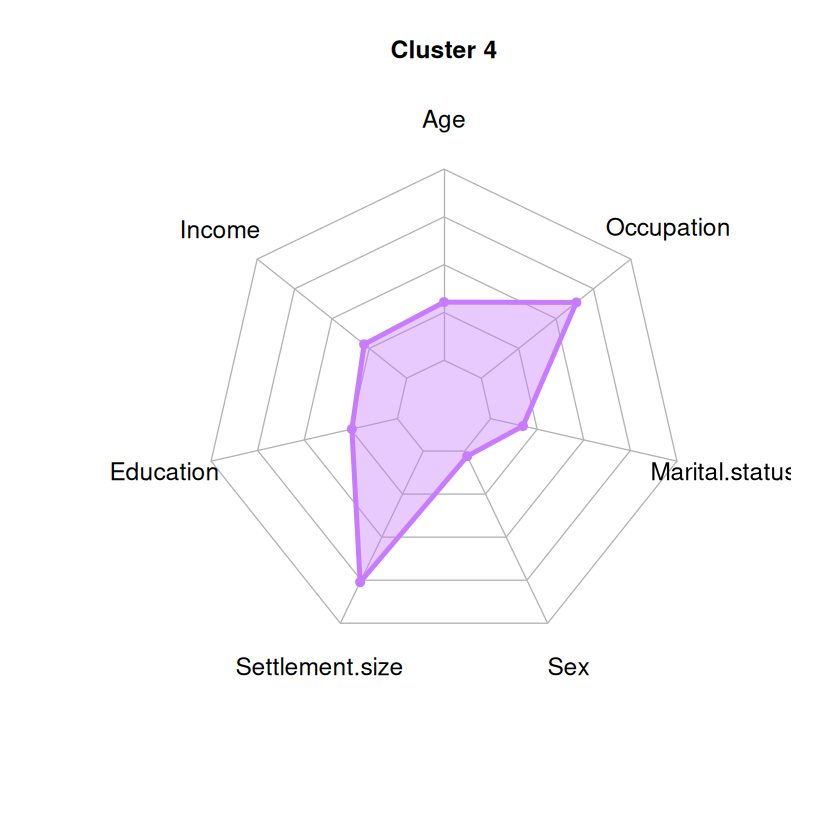

In [64]:
# Radar graph, visualização dos valores médios de cada cluster.

radarGraphOutput <- function(group, titulo, cor_hex) {
  grupo_media <- group %>%
    select(Age, Income, Education, Settlement.size, Sex, Marital.status, Occupation) %>%
    summarise(across(everything(), mean, na.rm = TRUE))

  maximos <- data.frame(Age = 76, Income = 270000, Education = 3, Settlement.size = 2, Sex = 1, Marital.status = 1, Occupation = 2) 
  minimos <- data.frame(Age = 18, Income = 90000,  Education = 0, Settlement.size = 0, Sex = 0, Marital.status = 0, Occupation = 0)  

  dados_radar <- rbind(maximos, minimos, grupo_media)

  radarchart(dados_radar,
             pcol = cor_hex,                                     
             pfcol = adjustcolor(cor_hex, alpha.f = 0.4),        
             plwd = 3,                  
             cglcol = "grey70",         
             cglty = 1,                 
             cglwd = 0.8,               
             vlcex = 1.2,               
             calcex = 0.8,
             title = titulo              
  )
}

radarGraphOutput(grupo_1, "Cluster 1", "#F8766D")
radarGraphOutput(grupo_2, "Cluster 2", "#7CAE00")
radarGraphOutput(grupo_3, "Cluster 3", "#00BFC4")
radarGraphOutput(grupo_4, "Cluster 4", "#C77CFF")

-----------------------------------------------
# Conclusão
-----------------------------------------------

A pergunta inicial foi: *Quais são os principais perfis/segmentos de clientes da loja com base em informações gerais sobre renda, ocupação, escolaridade, etc?*

Como feito na interpretação dos resultados do modelo, encontramos e caracterizamos 4 agrupamentos de acordo com as informações disponibilizadas.

- Dado que o agrupamento mais populoso é o representado por mulheres jovens não solteiras, compondo 35,25% do dataset, seria interessante que o comércio fizesse uma campanha de incentivo ao consumo voltado a esse público.

- Observa-se que existe um grupo de clientes, o representado por pessoas mais velhas, com maior renda e escolaridade, que pode ser melhor explorado pelo setor de relação com cliente, visto o potencial financeiro que esse grupo possui.

Dentre algumas limitações que observamos durante o projeto, vale citar:

- O dataset pode ser criticado pela baixa quantidade de variáveis / colunas e pelo pouco volume de linhas.

- O K-means é um algoritmo simplório, que talvez não reflita da melhor forma a realidade. Além disso, Observa-se uma quantidade considerável de *outliers*, que impactam negativamente no desempenho do algoritmo.